In [226]:
import pandas as pd
import re
import os
import paramiko
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from pprint import pprint
from itertools import chain
from sqlalchemy import create_engine
ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy()) 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

In [320]:
sample_data = {
    "Sample_1": np.random.normal(50, 10, 1000),
    "Sample_2": np.random.normal(60, 15, 1000),
    "Sample_3": np.random.normal(55, 20, 1000)
}

# Convert data to long format for seaborn
data_long = pd.DataFrame(sample_data)

data_long


,Sample_1,Sample_2,Sample_3
0,38.097691,54.489909,75.490281
1,54.792799,52.420020,83.864253
2,61.555106,76.229611,38.452385
3,45.954205,61.306644,87.658160
4,42.432410,85.760711,58.104890
...,...,...,...
995,68.949541,37.390262,61.680969
996,35.081301,60.426033,85.319229
997,39.517323,87.706383,21.625271
998,51.202531,57.541526,17.264220


In [325]:
data_long = data_long.melt(var_name="Sample", value_name="Value")

In [330]:
data_long

,Sample,Value
0,Sample_1,47.928741
1,Sample_1,32.203939
2,Sample_1,39.921575
3,Sample_1,51.101459
4,Sample_1,57.196170
...,...,...
2995,Sample_3,29.732354
2996,Sample_3,63.627441
2997,Sample_3,52.364036
2998,Sample_3,51.666299


In [327]:

import plotly.express as px

# Create a plotly figure
fig = px.histogram(
    data_long,
    x="Value",
    color="Sample",
    nbins=30,
    histnorm="probability density",  # Normalized histogram for density
    marginal="box",  # Optional: adds boxplots for each sample
    title="Distribution Across Samples"
)

fig.update_layout(xaxis_title="Value", yaxis_title="Density")
fig.show()

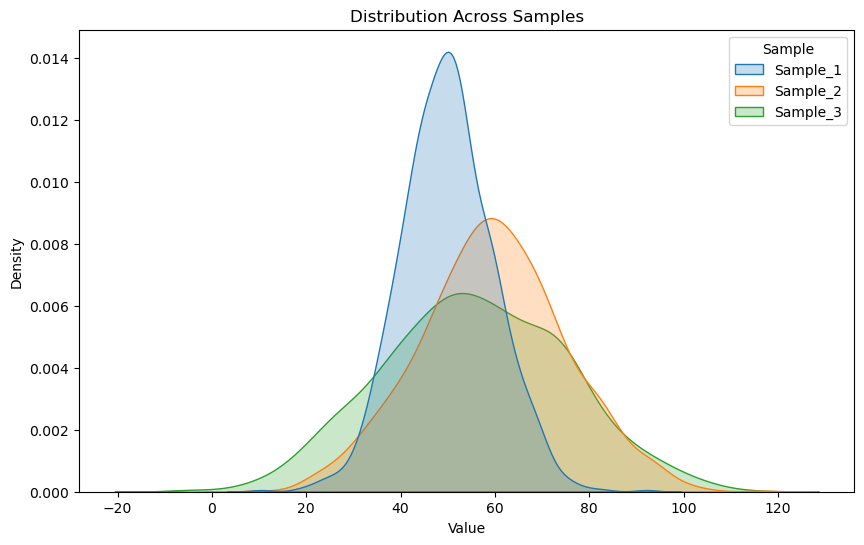

In [328]:


# Plot the distributions
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data_long, x="Value", hue="Sample", fill=True)
plt.title("Distribution Across Samples")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

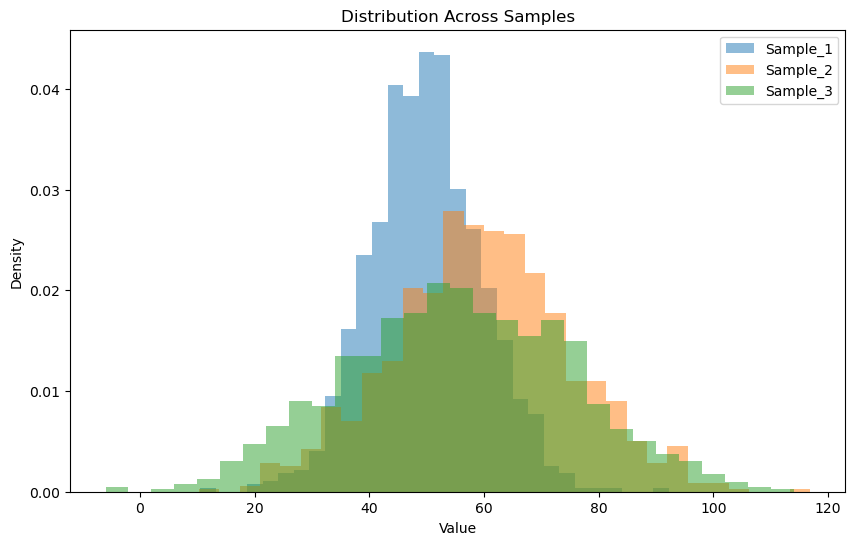

In [329]:
# Plot distributions with matplotlib
plt.figure(figsize=(10, 6))

for sample_name, values in sample_data.items():
    plt.hist(values, bins=30, alpha=0.5, label=sample_name, density=True)  # Use density=True for a normalized histogram

plt.title("Distribution Across Samples")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

In [338]:
l4l5_rlens = pd.read_csv(r'c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\length_counts_all.csv')

l4l5_rlens = l4l5_rlens.pivot(columns='Read_Length', index='File_Path', values='Count')
l4l5_rlens.columns.name = None
l4l5_rlens = l4l5_rlens.reset_index()
cols_to_drop = l4l5_rlens.columns[1:]
l4l5_rlens = l4l5_rlens.fillna(0)
l4l5_rlens['Distribution'] = l4l5_rlens[cols_to_drop].apply(list, axis=1)
l4l5_rlens = l4l5_rlens.drop(columns=cols_to_drop)

l4l5_rlens['prod'] = l4l5_rlens['File_Path'].apply(lambda x: x.split('/')[4])

nsx_rlens = l4l5_rlens[l4l5_rlens['prod']=='results'].copy()
nsx_rlens['flowcell'] = nsx_rlens['File_Path'].apply(lambda x: x.split('/')[-7].split('_')[-1]).apply(lambda x: 'AHNLW5DSX5' if x == 'AOZCK' else 'BH5F5KDSX7')
nsx_rlens ['basename'] = nsx_rlens['File_Path'].apply(lambda x: x.split('/')[-1])
nsx_rlens['trim_type'] = nsx_rlens['basename'].apply(lambda x: x.split('_')[3].split('.')[0])
nsx_rlens['lib'] = nsx_rlens['basename'].apply(lambda x: x.split('_')[1])

ns6_rlens = l4l5_rlens[l4l5_rlens['prod']=='production'].copy()
ns6_rlens['basename'] = ns6_rlens['File_Path'].apply(lambda x: x.split('/')[-1])
ns6_rlens['flowcell'] = ns6_rlens['File_Path'].apply(lambda x: x.split('/')[-5].split('_')[1])
ns6_rlens['trim_type'] = ns6_rlens['basename'].apply(lambda x: x.split('_')[3].split('.')[0])
ns6_rlens['lib'] = ns6_rlens['basename'].apply(lambda x: x.split('_')[1])

l4l5_rlens = pd.concat([ns6_rlens, nsx_rlens])
l4l5_rlens['Platform'] = l4l5_rlens['prod'].apply(lambda x: 'NovaSeqX' if x == 'results' else 'NovaSeq6')
l4l5_rlens ['Protocol'] = l4l5_rlens['flowcell'].apply(lambda x: 'Double' if x == 'AHNLW5DSX5' else 'Single')
l4l5_rlens['Lane'] = l4l5_rlens.basename.apply(lambda x: x.split("_")[2])

In [343]:
l4l5_rlens['Distribution'][1]

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 2.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 4.0,
 2.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 2490.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 

ss ns6 lane 4

In [332]:
l4l5_rlens = pd.read_csv(r'c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\length_counts_all.csv')
l4l5_rlens['prod'] = l4l5_rlens['File_Path'].apply(lambda x: x.split('/')[4])

nsx_rlens = l4l5_rlens[l4l5_rlens['prod']=='results'].copy()
nsx_rlens['flowcell'] = nsx_rlens['File_Path'].apply(lambda x: x.split('/')[-7].split('_')[-1]).apply(lambda x: 'AHNLW5DSX5' if x == 'AOZCK' else 'BH5F5KDSX7')
nsx_rlens ['basename'] = nsx_rlens['File_Path'].apply(lambda x: x.split('/')[-1])
nsx_rlens['trim_type'] = nsx_rlens['basename'].apply(lambda x: x.split('_')[3].split('.')[0])
nsx_rlens['lib'] = nsx_rlens['basename'].apply(lambda x: x.split('_')[1])

ns6_rlens = l4l5_rlens[l4l5_rlens['prod']=='production'].copy()
ns6_rlens['basename'] = ns6_rlens['File_Path'].apply(lambda x: x.split('/')[-1])
ns6_rlens['flowcell'] = ns6_rlens['File_Path'].apply(lambda x: x.split('/')[-5].split('_')[1])
ns6_rlens['trim_type'] = ns6_rlens['basename'].apply(lambda x: x.split('_')[3].split('.')[0])
ns6_rlens['lib'] = ns6_rlens['basename'].apply(lambda x: x.split('_')[1])

l4l5_rlens = pd.concat([ns6_rlens, nsx_rlens])
l4l5_rlens['Platform'] = l4l5_rlens['prod'].apply(lambda x: 'NovaSeqX' if x == 'results' else 'NovaSeq6')
l4l5_rlens ['Protocol'] = l4l5_rlens['flowcell'].apply(lambda x: 'Double' if x == 'AHNLW5DSX5' else 'Single')
l4l5_rlens['Lane'] = l4l5_rlens.basename.apply(lambda x: x.split("_")[2])

In [333]:
l4l5_rlens

,Read_Length,Count,File_Path,prod,basename,flowcell,trim_type,lib,Platform,Protocol,Lane
37159,0,4,results_full2/projects/caeg/data/production/LV...,production,Lib_LV7008958558_L004_discarded.fastq.gz_lengt...,BH5F5KDSX7,discarded,LV7008958558,NovaSeq6,Single,L004
37160,4,1,results_full2/projects/caeg/data/production/LV...,production,Lib_LV7008958558_L004_discarded.fastq.gz_lengt...,BH5F5KDSX7,discarded,LV7008958558,NovaSeq6,Single,L004
37161,6,3,results_full2/projects/caeg/data/production/LV...,production,Lib_LV7008958558_L004_discarded.fastq.gz_lengt...,BH5F5KDSX7,discarded,LV7008958558,NovaSeq6,Single,L004
37162,7,2,results_full2/projects/caeg/data/production/LV...,production,Lib_LV7008958558_L004_discarded.fastq.gz_lengt...,BH5F5KDSX7,discarded,LV7008958558,NovaSeq6,Single,L004
37163,8,8,results_full2/projects/caeg/data/production/LV...,production,Lib_LV7008958558_L004_discarded.fastq.gz_lengt...,BH5F5KDSX7,discarded,LV7008958558,NovaSeq6,Single,L004
...,...,...,...,...,...,...,...,...,...,...,...
37154,93,7,results_full2/projects/caeg/data/results/NovaS...,results,Lib_LV7009026476_L005_discarded.fastq.gz_lengt...,AHNLW5DSX5,discarded,LV7009026476,NovaSeqX,Double,L005
37155,94,1,results_full2/projects/caeg/data/results/NovaS...,results,Lib_LV7009026476_L005_discarded.fastq.gz_lengt...,AHNLW5DSX5,discarded,LV7009026476,NovaSeqX,Double,L005
37156,95,2,results_full2/projects/caeg/data/results/NovaS...,results,Lib_LV7009026476_L005_discarded.fastq.gz_lengt...,AHNLW5DSX5,discarded,LV7009026476,NovaSeqX,Double,L005
37157,96,1,results_full2/projects/caeg/data/results/NovaS...,results,Lib_LV7009026476_L005_discarded.fastq.gz_lengt...,AHNLW5DSX5,discarded,LV7009026476,NovaSeqX,Double,L005


In [345]:
# Plot the distributions
plt.figure(figsize=(10, 6))
sns.kdeplot(data=l4l5_rlens, x="Distribution", fill=True)
plt.title("Distribution Across Samples")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3662736109.py, line 3)

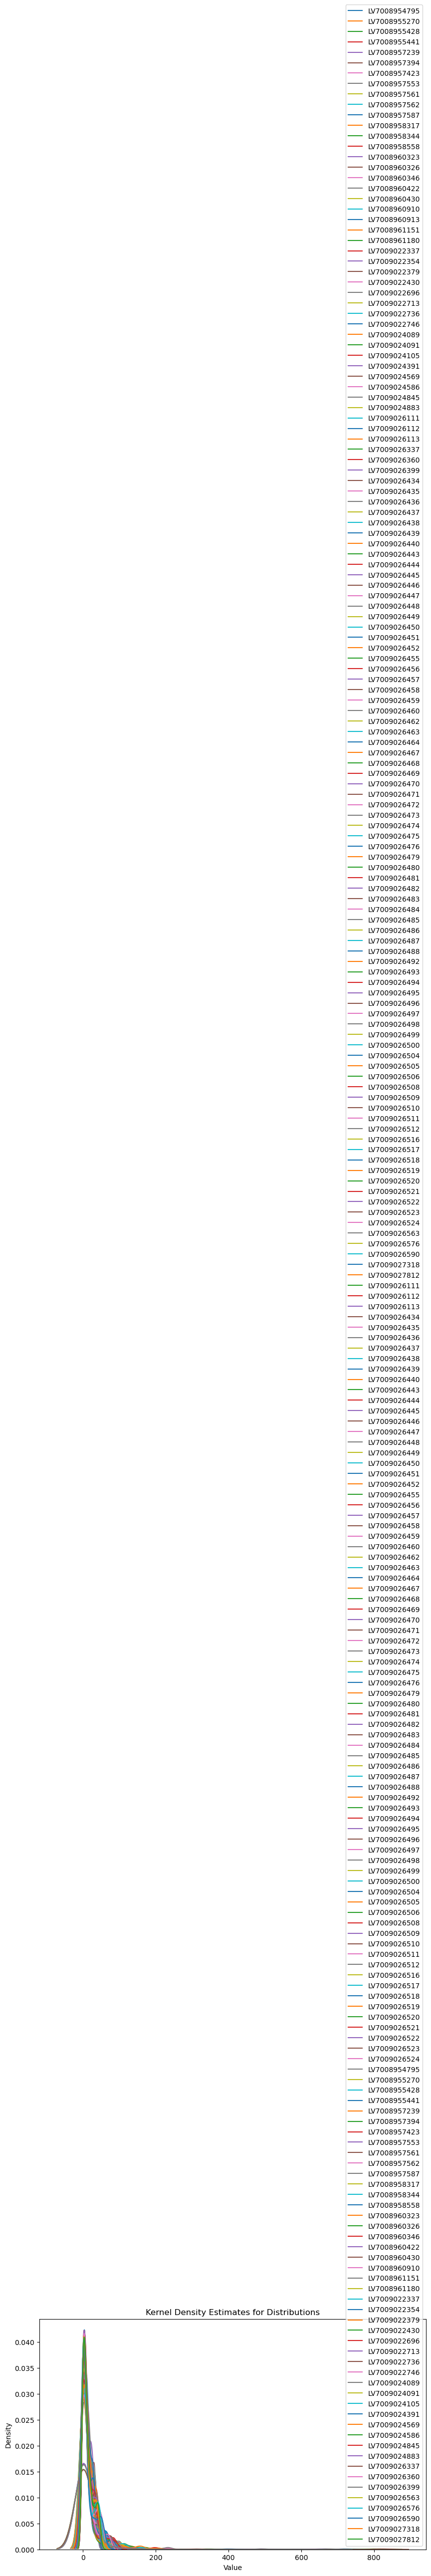

In [349]:
# Plot each distribution
plt.figure(figsize=(10, 6))
for _, row in l4l5_rlens[l4l5_rlens['trim_type']=='collapsed'].iterrows():
    sns.kdeplot(
        row['Distribution'], 
        label=row['lib'],
        legend=False
        
    )

# Add title and labels
plt.title("Kernel Density Estimates for Distributions")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

In [351]:
# Create a figure
fig = go.Figure()

# Add a KDE trace for each distribution
for _, row in l4l5_rlens[(l4l5_rlens['trim_type']=='collapsed') 
                         & (l4l5_rlens['Platform'] == 'NovaSeqX')
                         & (l4l5_rlens.Protocol == 'Double')].iterrows():
    fig.add_trace(go.Violin(
        x0=row['lib'],  # Distribution ID as the grouping variable
        y=row['Distribution'],  # Values to plot
        name=row['lib'],  # Legend label
        box_visible=True,  # Show box plot inside the violin
        meanline_visible=True  # Show mean line
    ))

# Update layout
fig.update_layout(
    title="KDE Plots for Distributions",
    xaxis_title="Distribution ID",
    yaxis_title="Value",
    violinmode='group'
)

# Show the plot
fig.show()

In [324]:
l4l5_rlens.sort_values('Read_Length')

,Read_Length,Count,File_Path,prod,basename,flowcell,trim_type,lib,Platform,Protocol,Lane
37159,0,4,results_full2/projects/caeg/data/production/LV...,production,Lib_LV7008958558_L004_discarded.fastq.gz_lengt...,BH5F5KDSX7,discarded,LV7008958558,NovaSeq6,Single,L004
37738,0,1,results_full2/projects/caeg/data/production/LV...,production,Lib_LV7008958344_L004_discarded.fastq.gz_lengt...,BH5F5KDSX7,discarded,LV7008958344,NovaSeq6,Single,L004
51846,0,14,results_full2/projects/caeg/data/production/LV...,production,Lib_LV7009026523_L004_discarded.fastq.gz_lengt...,AHNLW5DSX5,discarded,LV7009026523,NovaSeq6,Double,L004
64170,0,13,results_full2/projects/caeg/data/production/LV...,production,Lib_LV7009026482_L004_discarded.fastq.gz_lengt...,AHNLW5DSX5,discarded,LV7009026482,NovaSeq6,Double,L004
64390,0,8,results_full2/projects/caeg/data/production/LV...,production,Lib_LV7009026499_L004_discarded.fastq.gz_lengt...,AHNLW5DSX5,discarded,LV7009026499,NovaSeq6,Double,L004
...,...,...,...,...,...,...,...,...,...,...,...
25183,190,3,results_full2/projects/caeg/data/results/NovaS...,results,Lib_LV7009026506_L005_collapsed.fastq.gz_lengt...,AHNLW5DSX5,collapsed,LV7009026506,NovaSeqX,Double,L005
29791,190,1,results_full2/projects/caeg/data/results/NovaS...,results,Lib_LV7009026480_L005_collapsed.fastq.gz_lengt...,AHNLW5DSX5,collapsed,LV7009026480,NovaSeqX,Double,L005
35595,190,3,results_full2/projects/caeg/data/results/NovaS...,results,Lib_LV7009026508_L005_collapsed.fastq.gz_lengt...,AHNLW5DSX5,collapsed,LV7009026508,NovaSeqX,Double,L005
31104,190,2,results_full2/projects/caeg/data/results/NovaS...,results,Lib_LV7009026498_L005_collapsed.fastq.gz_lengt...,AHNLW5DSX5,collapsed,LV7009026498,NovaSeqX,Double,L005


In [ ]:
# Plot the distributions
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data_long, x="Value", hue="Sample", fill=True)
plt.title("Distribution Across Samples")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

In [243]:
# Filter data for the bar plot
bar_data = l4l5_rlens[(l4l5_rlens['trim_type'] == 'collapsed') 
                      & (l4l5_rlens['Protocol'] == 'Single')
                      & (l4l5_rlens['Platform'] == 'NovaSeq6')]

# Create the bar plot
fig = go.Figure()

fig.add_trace(go.Bar(
    x=bar_data['Read_Length'],  # X-axis: Read_Length
    y=bar_data['Count'],        # Y-axis: Count
    name='Single NovaSeq6',     # Label for the bar plot
    marker_color='blue'         # Set the bar color
))

# Update layout to add title and axis labels
fig.update_layout(
    title='Bar Plot for Single Protocol and NovaSeq6',
    xaxis_title='Read Length',
    yaxis_title='Count',
    xaxis_tickangle=90,  # Rotate x-axis labels if needed
    width=1000,  # Set the width of the plot (adjust as needed)
    height=600   # Set the height of the plot (adjust as needed)
)

# Show the plot
fig.show()

In [239]:
import plotly.graph_objects as go

# Filter data for the first and second lines
ds_nsx_data = l4l5_rlens[(l4l5_rlens['trim_type'] == 'collapsed') 
                         & (l4l5_rlens['Protocol'] == 'Double')
                         & (l4l5_rlens['Platform'] == 'NovaSeqX')]

ds_ns6_data = l4l5_rlens[(l4l5_rlens['trim_type'] == 'collapsed') 
                         & (l4l5_rlens['Protocol'] == 'Double')
                         & (l4l5_rlens['Platform'] == 'NovaSeq6')]

# Create the plot
fig = go.Figure()

# Plot the first line (ds nsx)
fig.add_trace(go.Bar(
    x=ds_nsx_data['Read_Length'],
    y=ds_nsx_data['Count'],
    mode='lines',  # Line plot
    name='ds nsx collapsed',  # Label for the first line
    line=dict(color='blue')  # Set a color for the first line
))

# Update layout to rotate x-axis labels and add title/labels
fig.update_layout(
    title='Comparison of ds nsx and ds ns6',
    xaxis_title='Read Length',
    yaxis_title='Count',
    xaxis_tickangle=90,  # Rotate x-axis tick labels
    width=1000,  # Set the width of the plot (adjust as needed)
    height=600  # Set the height of the plot (adjust as needed)
)

# Show the plot
fig.show()


ValueError: Invalid property specified for object of type plotly.graph_objs.Bar: 'line'

Did you mean "base"?

    Valid properties:
        alignmentgroup
            Set several traces linked to the same position axis or
            matching axes to the same alignmentgroup. This controls
            whether bars compute their positional range dependently
            or independently.
        base
            Sets where the bar base is drawn (in position axis
            units). In "stack" or "relative" barmode, traces that
            set "base" will be excluded and drawn in "overlay" mode
            instead.
        basesrc
            Sets the source reference on Chart Studio Cloud for
            `base`.
        cliponaxis
            Determines whether the text nodes are clipped about the
            subplot axes. To show the text nodes above axis lines
            and tick labels, make sure to set `xaxis.layer` and
            `yaxis.layer` to *below traces*.
        constraint

ss ns6 lane 4

C:\Users\glj523\AppData\Local\Temp\ipykernel_19104\150635415.py:5: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




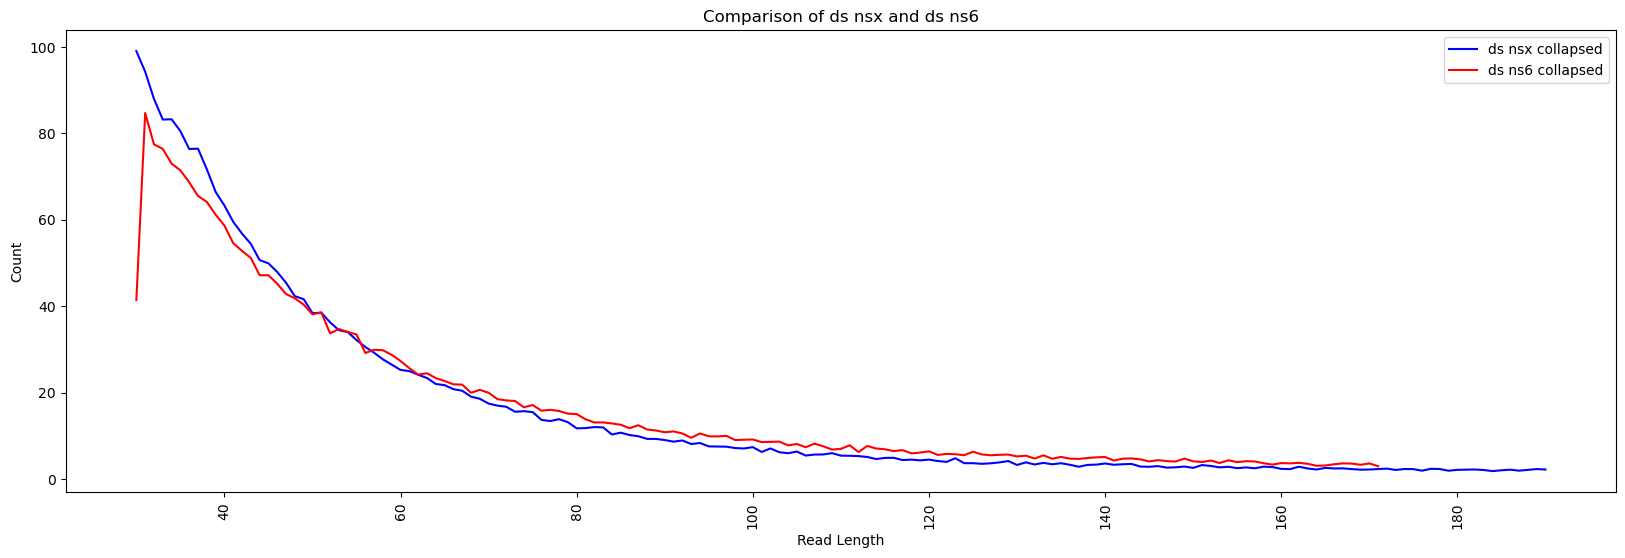

In [230]:



# Set the figure size to be wider
plt.figure(figsize=(20, 6))

# Plot the first line (ds nsx)
sns.lineplot(
    data=l4l5_rlens[(l4l5_rlens['trim_type'] == 'collapsed') 
                    & (l4l5_rlens['Protocol'] == 'Double')
                    & (l4l5_rlens['Platform'] == 'NovaSeqX')],
    x='Read_Length',
    y='Count',
    ci=None,
    label='ds nsx collapsed',  # Label for the first line
    color='blue'  # Set a color for the first line
)

# Plot the second line (ds ns6)
sns.lineplot(
    data=l4l5_rlens[(l4l5_rlens['trim_type'] == 'collapsed') 
                    & (l4l5_rlens['Protocol'] == 'Double')
                    & (l4l5_rlens['Platform'] == 'NovaSeq6')],
    x='Read_Length',
    y='Count',
    errorbar=None,
    label='ds ns6 collapsed',  # Label for the second line
    color='red'  # Set a color for the second line
)

# Rotate x-axis tick labels
plt.xticks(rotation=90)

# Add title and labels
plt.title('Comparison of ds nsx and ds ns6')
plt.xlabel('Read Length')
plt.ylabel('Count')

# Display legend
plt.legend()

# Display the combined plot
plt.show()






C:\Users\glj523\AppData\Local\Temp\ipykernel_19104\590811081.py:2: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




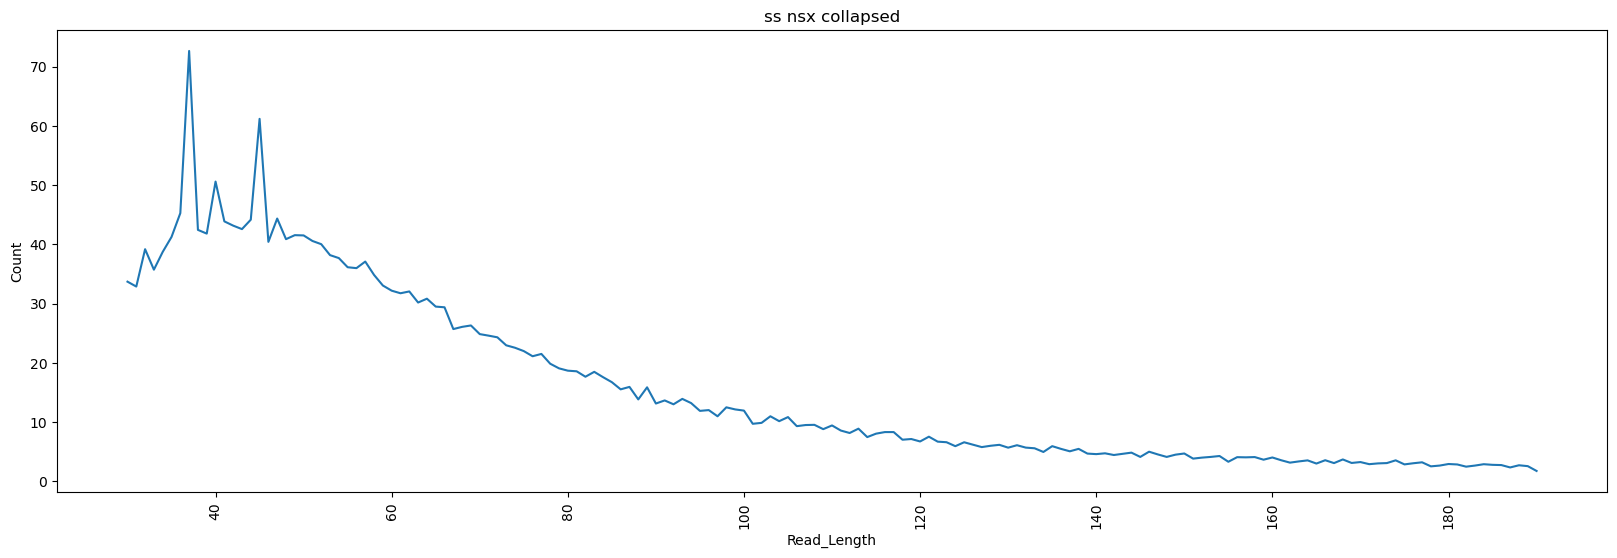

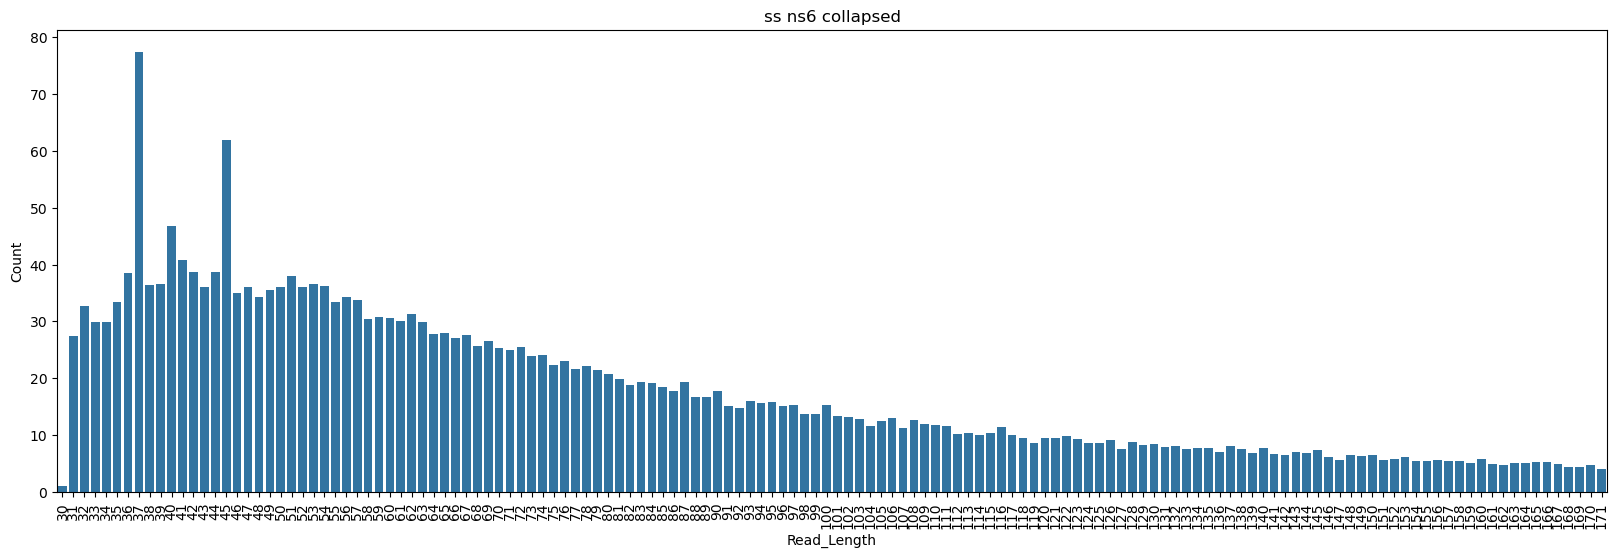

In [240]:
plt.figure(figsize=(20, 6))
sns.lineplot(
    data=l4l5_rlens[(l4l5_rlens['trim_type'] == 'collapsed') 
                    & (l4l5_rlens['Protocol'] == 'Single')
                    & (l4l5_rlens['Platform'] == 'NovaSeqX')],
    x='Read_Length',
    y='Count',
    ci=None
)

# Rotate x-axis tick labels
plt.xticks(rotation=90)
plt.title('ss nsx collapsed')

# Display the plot
plt.show()


plt.figure(figsize=(20, 6))
sns.barplot(
    data=l4l5_rlens[(l4l5_rlens['trim_type'] == 'collapsed') 
                    & (l4l5_rlens['Protocol'] == 'Single')
                    & (l4l5_rlens['Platform'] == 'NovaSeq6')],
    x='Read_Length',
    y='Count',
    errorbar=None
)

# Rotate x-axis tick labels
plt.xticks(rotation=90)
plt.title('ss ns6 collapsed')

plt.show()

In [117]:
nsx_ds_multiqc = pd.read_csv(r'c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\abidmux_qc_AOZCK_full.csv')
all_ns6_multiqc = pd.read_csv(r'c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\all_ns6_multiqc.csv')
nsx_ss_multiqc = pd.read_csv(r'c:\Users\glj523\OneDrive - University of Copenhagen\data\illumina_analysis\ill_dmux_multiqc_ss_full.csv')

nsx_ss_multiqc['Protocol'] = 'Single'
nsx_ds_multiqc['Protocol'] = 'Double'

all_nsx_multiqc = pd.concat([nsx_ds_multiqc, nsx_ss_multiqc]).reset_index(drop=True)
all_nsx_multiqc['Platform'] = 'NovaSeqX'

# Remove diffs
diff_lib = set(all_nsx_multiqc.library_id) ^ set(all_ns6_multiqc.library_id) 
all_nsx_multiqc = all_nsx_multiqc[~all_nsx_multiqc['library_id'].isin(diff_lib)]
all_ns6_multiqc = all_ns6_multiqc[~all_ns6_multiqc['library_id'].isin(diff_lib)]
print(f'removed {diff_lib} from dataframes')

all_nsx_multiqc['Lane'] = all_nsx_multiqc['suffix'].apply(lambda x: x.split('_')[0])
all_nsx_multiqc['Read Type'] = all_nsx_multiqc['suffix'].apply(lambda x: x.split('_')[1] if len(x.split('_')) > 1 else None)
diff_cols = set(all_ns6_multiqc.columns) ^ set(all_nsx_multiqc.columns)

all_nsx_multiqc = all_nsx_multiqc.drop(columns=diff_cols, errors='ignore')
all_ns6_multiqc = all_ns6_multiqc.drop(columns=diff_cols, errors='ignore')
print(f'removed {diff_cols} from dataframes')

all_multiqc_data = pd.concat([all_ns6_multiqc, all_nsx_multiqc]).reset_index(drop=True)

data_ns6 = all_ns6_multiqc
data_nsX = all_nsx_multiqc
data_ns6_ss = data_ns6[data_ns6['Protocol'] == 'Single']
data_nsX_ss = data_nsX[data_nsX['Protocol'] == 'Single']
data_ns6_ds = data_ns6[data_ns6['Protocol'] == 'Double']
data_nsX_ds = data_nsX[data_nsX['Protocol'] == 'Double']

removed {'LV7009026461', 'LV7008960913'} from dataframes
removed {'suffix', 'Project', 'qc_type', 'eDNA Concentration', 'fastq_id', 'config_output_dir'} from dataframes


In [126]:
data_nsX_ss.Lane.unique()

array(['L001', 'collapsed', 'collapsed.bact', 'collapsed.norway.1-of-7',
       'collapsed.norway.2-of-7', 'collapsed.norway.3-of-7',
       'collapsed.norway.4-of-7', 'collapsed.norway.5-of-7',
       'collapsed.norway.6-of-7', 'collapsed.norway.7-of-7',
       'collapsed.nt.1-of-9', 'collapsed.nt.2-of-9',
       'collapsed.nt.3-of-9', 'collapsed.nt.4-of-9',
       'collapsed.nt.5-of-9', 'collapsed.nt.6-of-9',
       'collapsed.nt.7-of-9', 'collapsed.nt.8-of-9',
       'collapsed.nt.9-of-9', 'collapsed.polar.1-of-1', 'collapsed.polar',
       'collapsed.refseq', 'L006', 'L005', 'L008', 'L004', 'L002', 'L003',
       'L007'], dtype=object)

Data validataion

In [4]:
assert set(all_nsx_multiqc.library_id) == set(all_ns6_multiqc.library_id)

In [5]:
sum_cols = ["fastqc_raw__Total Sequences", "fastqc_trimmed__Total Sequences"]
box_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"] 

Percentage of reads aligned out of total number of collapsed reads

In [6]:
print(data_ns6[data_ns6['Read Type'] == 'collapsed']['reads_aligned'].sum() / data_ns6[data_ns6['Read Type'] == 'collapsed']['fastqc_trimmed__Total Sequences'].sum() * 100)
print(data_nsX[data_nsX['Read Type'] == 'collapsed']['reads_aligned'].sum() / data_nsX[data_nsX['Read Type'] == 'collapsed']['fastqc_trimmed__Total Sequences'].sum() * 100)

KeyError: 'reads_aligned'

Same as above but per lane, single

In [7]:
protocol = 'Double'

g1 = \
    (data_ns6[
        (data_ns6['Read Type'] == 'collapsed') 
        & (data_ns6['Protocol'] == protocol)][
            ['Lane', 'reads_aligned']]
     .groupby('Lane')
     .sum()
     .reset_index()
     .sort_values('Lane')
     .reset_index(drop=True))
divider = (data_ns6[
    (data_ns6['Read Type'] == 'collapsed') 
    & (data_ns6['Protocol'] == protocol)][
        ['Lane', 'fastqc_trimmed__Total Sequences']
        ]
 .groupby('Lane')
 .sum()
 .reset_index()
 .sort_values('Lane')
 .reset_index(drop=True)
 )
g1['reads_aligned'] = g1['reads_aligned'] / divider['fastqc_trimmed__Total Sequences'] * 100
g2 = \
    (data_nsX[
        (data_nsX['Read Type'] == 'collapsed') 
        & (data_nsX['Protocol'] == protocol)][
            ['Lane', 'reads_aligned']]
     .groupby('Lane')
     .sum()
     .reset_index()
     .sort_values('Lane')
     .reset_index(drop=True))
divider = (data_nsX[
    (data_nsX['Read Type'] == 'collapsed') 
    & (data_nsX['Protocol'] == protocol)][
        ['Lane', 'fastqc_trimmed__Total Sequences']
        ]
 .groupby('Lane')
 .sum()
 .reset_index()
 .sort_values('Lane')
 .reset_index(drop=True)
 )
g2['reads_aligned'] = g2['reads_aligned'] / divider['fastqc_trimmed__Total Sequences'] * 100
g1.plot(kind='bar', x='Lane', ylabel='reads_aligned', ylim=(0,8), legend=False).set_title('NovaSeq6000')
g2.plot(kind='bar', x='Lane', ylabel='reads_aligned', ylim=(0,8), legend=False).set_title('NovaSeqX')

KeyError: "['reads_aligned'] not in index"

Scatter plot of total raw reads per library

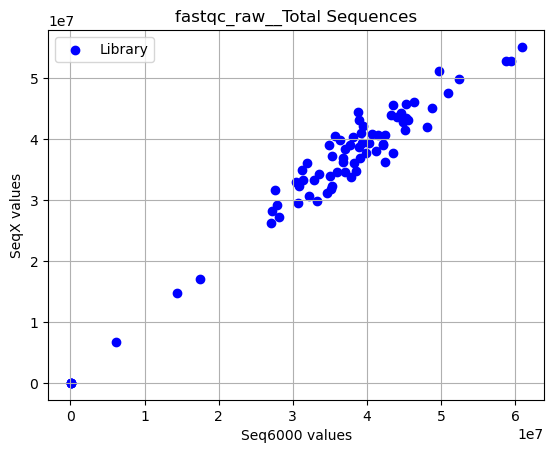

In [8]:
def scatter_plot(full_dataset, protocol, value_column):
    if protocol == "Single":
        filter = full_dataset["Protocol"] == "Single"
    
    elif protocol == "Double":
        filter = full_dataset["Protocol"] == "Double"
    
    elif protocol == "Both":
        filter = (full_dataset["Protocol"] == "Single") | (full_dataset["Protocol"] == "Double")
        
    else:
        raise Exception()
    
    full_dataset = full_dataset[filter]
    data_nsX = full_dataset[(full_dataset["Platform"] == "NovaSeqX") & (full_dataset["Read Type"] == "R1") & (full_dataset["Lane"] == "L005")]
    data_ns6 = full_dataset[(full_dataset["Platform"] == "NovaSeq6") & (full_dataset["Read Type"] == "R1") & (full_dataset["Lane"] == "L004")]
    
    x = data_nsX[["library_id", value_column]].groupby("library_id").sum().reset_index().sort_values("library_id")[value_column]
    y = data_ns6[["library_id", value_column]].groupby("library_id").sum().reset_index().sort_values("library_id")[value_column]

    # Create scatter plot
    plt.scatter(y, x, color='blue', label='Library', marker='o')
    
    # Customize the plot
    plt.title(value_column)  # Add a title
    plt.xlabel("Seq6000 values")  # Label for x-axis
    plt.ylabel("SeqX values")  # Label for y-axis
    plt.legend()  # Show legend
    plt.grid(True)  # Add gridlines
    plt.show()  # Display the plot
scatter_plot(all_multiqc_data, "Double", "fastqc_raw__Total Sequences")

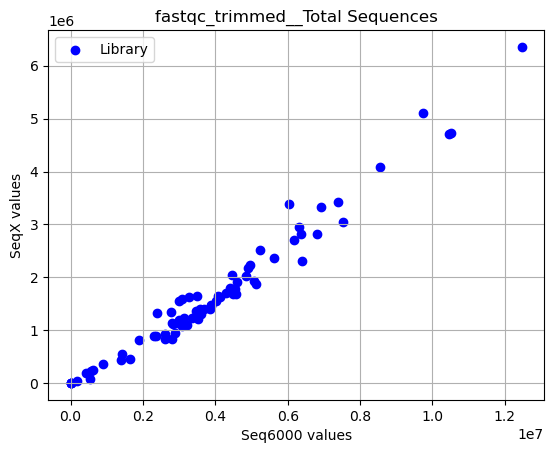

In [9]:
scatter_plot(all_multiqc_data, "Double", "fastqc_trimmed__Total Sequences")

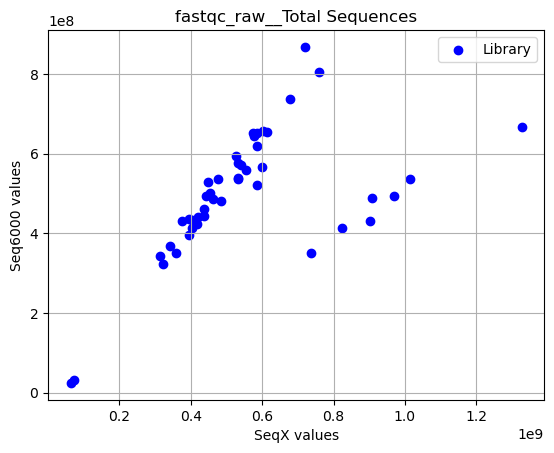

In [10]:
def scatter_plot(value):
    x = data_nsX[data_nsX["Protocol"] == "Single"][["library_id", value]].groupby("library_id").sum().reset_index().sort_values("library_id")[value]
    y = data_ns6[data_ns6["Protocol"] == "Single"][["library_id", value]].groupby("library_id").sum().reset_index().sort_values("library_id")[value]

    # Create scatter plot
    plt.scatter(x, y, color='blue', label='Library', marker='o')

    # Customize the plot
    plt.title("fastqc_raw__Total Sequences")  # Add a title
    plt.xlabel("SeqX values")  # Label for x-axis
    plt.ylabel("Seq6000 values")  # Label for y-axis
    plt.legend()  # Show legend
    plt.grid(True)  # Add gridlines
    plt.show()  # Display the plot
scatter_plot("fastqc_raw__Total Sequences")

Compare raw output between lanes on NovaSeqX:

In [11]:

# Data selection and grouping
group_ns6 = data_ns6[(data_ns6["Protocol"] == "Double") & (data_ns6["Read Type"] == "R1") & (data_ns6["Lane"] == "L003")][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset_ns6 = group_ns6[group_ns6["fastqc_raw__Total Sequences"] > 0].reset_index()

group_nsX = data_nsX[(data_nsX["Protocol"] == "Double") & (data_nsX["Lane"] == "L005") & (data_nsX["Read Type"] == "R1")][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset_nsX = group_nsX[group_nsX["fastqc_raw__Total Sequences"] > 0].reset_index()

hover_template = "%{y}<extra></extra>"

# Create a single plot
fig = go.Figure()

# Add NS6 data
fig.add_trace(
    go.Bar(
        x=group_reset_ns6["Lane"],
        y=group_reset_ns6["fastqc_raw__Total Sequences"] / 1e9,  # Convert to billions for the bar height
        name="NovaSeq6000",
        text=group_reset_ns6["fastqc_raw__Total Sequences"] / 1e9,  # Convert to billions for the text
        texttemplate="%{text:.2f}B",  # Format text as billions with 2 decimal places
        textposition="auto",  # Automatically position the text
        hovertemplate=hover_template
    )
)

# Add NSX data with formatted text as billions
fig.add_trace(
    go.Bar(
        x=group_reset_nsX["Lane"],
        y=group_reset_nsX["fastqc_raw__Total Sequences"] / 1e9,  # Convert to billions for the bar height
        name="NovaSeq X",
        text=group_reset_nsX["fastqc_raw__Total Sequences"] / 1e9,  # Convert to billions for the text
        texttemplate="%{text:.2f}B",  # Format text as billions with 2 decimal places
        textposition="auto",  # Automatically position the text
        hovertemplate=hover_template
    )
)

# Update layout
fig.update_layout(
    height=600,
    width=800,
    yaxis_title="Count (Billions)",
    yaxis_tickformat="~s",  # Format the y-axis scale to show large numbers with suffixes like 'B'
    barmode="group",  # Use grouped bars
    title="Total Raw Read Pairs",
    xaxis_title="Lane",
    legend_title="Dataset"
)

# Show the figure
fig.show()


In [12]:
difference = group_reset_ns6['fastqc_raw__Total Sequences'] - group_reset_nsX['fastqc_raw__Total Sequences'].iloc[0]
group_reset_ns6['abs_difference'] = difference

# Create a single plot
fig = go.Figure()


# Add NS6 data
fig.add_trace(
    go.Bar(
        x=group_reset_ns6["Lane"],
        y=group_reset_ns6["abs_difference"],
        name="",
        hovertemplate=hover_template,
        showlegend=False  # Ensure mean appears in the legend
    )
)

mean_difference = group_reset_ns6['abs_difference'].mean()


# Overlay mean value as a dashed line
fig.add_trace(
    go.Scatter(
        x=group_reset_ns6["Lane"],
        y=[mean_difference] * len(group_reset_ns6),  # Mean line
        mode="lines",  # Add markers to the line
        name="Mean",
        line=dict(
            color="black",  # Set the color to re
            dash="dot",
            width=3       # Set line thickness
        ),
        showlegend=True  # Ensure mean appears in the legend
    )
)

# Add an annotation for the mean
fig.add_annotation(
    x=0.5,  # Adjust to position annotation centrally
    y=mean_difference + 1000000,
    xref="paper",
    yref="y",
    text=f"{mean_difference / 1_000_000:.2f}M",
    showarrow=False,
    font=dict(color="black", size=16)
)

# Update layout
fig.update_layout(
    height=600, width=800,
    yaxis_title="Difference",
    # yaxis_range=[0, 3e10],
    barmode="group",  # Use grouped bars
    title="R1 Sequences Count Difference",
    xaxis_title="Lane",
    legend_title="Dataset"
)

# Show the figure
fig.show()


In [13]:
difference = group_reset_ns6['abs_difference'] / group_reset_ns6['fastqc_raw__Total Sequences'] * 100
group_reset_ns6['percent_difference'] = difference

# Create the plot
fig = go.Figure()

# Add NS6 data as bars
fig.add_trace(
    go.Bar(
        x=group_reset_ns6["Lane"],
        y=group_reset_ns6["percent_difference"],
        name="Percent Difference",
        hovertemplate="%{y:.2f}%<extra></extra>"
    )
)

mean_difference = group_reset_ns6['percent_difference'].mean()

# Overlay mean value as a dashed line
fig.add_trace(
    go.Scatter(
        x=group_reset_ns6["Lane"],
        y=[mean_difference] * len(group_reset_ns6),  # Mean line
        mode="lines",  # Add markers to the line
        name="Mean",
        line=dict(
            color="black",  # Set the color to re
            dash="dot",
            width=3       # Set line thickness
        ),
        showlegend=True  # Ensure mean appears in the legend
    )
)

# Add an annotation for the mean
fig.add_annotation(
    x=0.5,  # Adjust to position annotation centrally
    y=mean_difference +0.05,
    xref="paper",
    yref="y",
    text=f"{mean_difference:.2f}%",
    showarrow=False,
    font=dict(color="black", size=16)
)

# Update layout
fig.update_layout(
    height=600,
    width=800,
    yaxis_title="Percent Difference",
    title="R1 Sequence Count Percent Difference",
    xaxis_title="Lane",
    legend_title="Dataset"
)

fig.show()

Compare raw output between lanes on NovaSeq6:

<Axes: title={'center': 'NovaSeq6 Double'}, xlabel='Lane'>

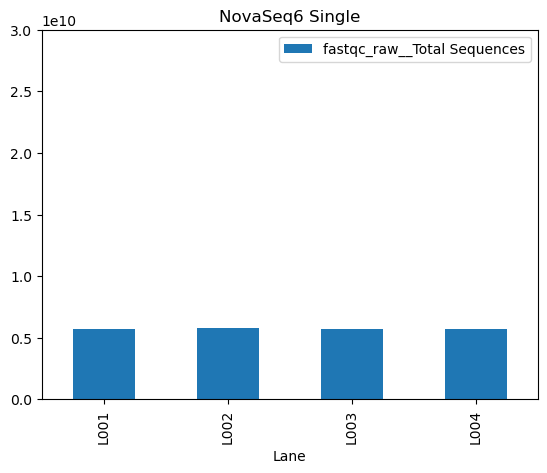

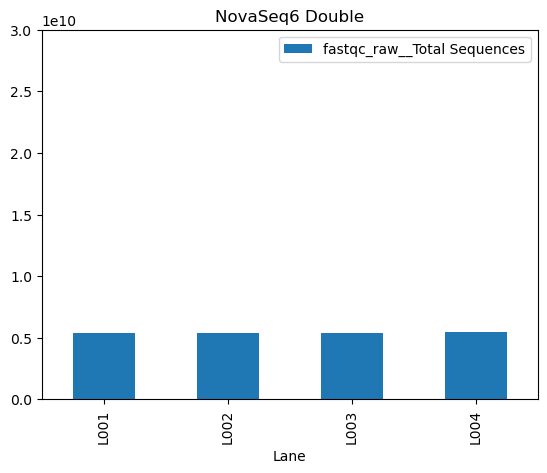

In [14]:
group = data_ns6[data_ns6["Protocol"] == "Single"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset = group[group["fastqc_raw__Total Sequences"] > 0].reset_index()
group_reset.plot(kind="bar", x="Lane", title="NovaSeq6 Single", ylim=(0, 3e10))

group = data_ns6[data_ns6["Protocol"] == "Double"][["Lane", "fastqc_raw__Total Sequences"]].groupby(["Lane"]).sum()
group_reset = group[group["fastqc_raw__Total Sequences"] > 0].reset_index()
group_reset.plot(kind="bar", x="Lane", title="NovaSeq6 Double", ylim=(0, 3e10))

Num of raw reads comparison single stranded

In [15]:
print("NovaSeqX: \t", all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeqX") & (all_multiqc_data["Protocol"] == "Single")]["fastqc_raw__Total Sequences"].sum() / 1000000000)
print("NovaSeq6000: \t", all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeq6") & (all_multiqc_data["Protocol"] == "Single")]["fastqc_raw__Total Sequences"].sum() / 1000000000)

NovaSeqX: 	 25.123163162
NovaSeq6000: 	 22.91257809


Num of raw reads comparison double stranded

In [16]:
print("NovaSeqX: \t", all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeqX") & (all_multiqc_data["Protocol"] == "Double")]["fastqc_raw__Total Sequences"].sum() / 1000000000)
print("NovaSeq6000: \t", all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeq6") & (all_multiqc_data["Protocol"] == "Double")]["fastqc_raw__Total Sequences"].sum() / 1000000000)

NovaSeqX: 	 5.345872524
NovaSeq6000: 	 21.632653832


Verify that all libraries have been sequenced on all lanes:

In [17]:
for id in all_multiqc_data["library_id"].unique():
    if len(all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeq6") & (~all_multiqc_data["fastqc_raw__Total Sequences"].isna()) & (all_multiqc_data["library_id"] == id)]["Lane"].unique()) != 4:
        print("Error")
        
for id in all_multiqc_data["library_id"].unique():
    if len(all_multiqc_data[(all_multiqc_data["Platform"] == "NovaSeqX") & (~all_multiqc_data["fastqc_raw__Total Sequences"].isna()) & (all_multiqc_data["library_id"] == id)]["Lane"].unique()) != 4:
        print("Error")

Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error
Error


Percentage of collapsed out of total on NS6

In [18]:
data_ns6[data_ns6["Read Type"] == "collapsed"]["fastqc_trimmed__Total Sequences"].sum() / data_ns6["fastqc_raw__Total Sequences"].sum() * 100

35.34489598026792

Percentage of collapsed out of total on NSX

In [19]:
print(data_nsX[data_nsX["Read Type"] == "collapsed"]["fastqc_trimmed__Total Sequences"].sum() / data_nsX["fastqc_raw__Total Sequences"].sum() * 100)
print(data_nsX_ds[data_nsX_ds["Read Type"] == "collapsed"]["fastqc_trimmed__Total Sequences"].sum() / data_nsX_ds["fastqc_raw__Total Sequences"].sum() * 100)
print(data_nsX_ss[data_nsX_ss["Read Type"] == "collapsed"]["fastqc_trimmed__Total Sequences"].sum() / data_nsX_ss["fastqc_raw__Total Sequences"].sum() * 100)

38.5215279307084
32.73477888115837
39.752870598341254


Percentage of discarded reads during fastp out of total reads

In [20]:
def get_total_after_fastp(platform):
    total_trimmed = 0
    for index, row in all_multiqc_data[all_multiqc_data["Platform"] == platform].iterrows():
        if row["Read Type"] == "collapsed":
            total_trimmed = total_trimmed + (row["fastqc_trimmed__Total Sequences"] * 2)
        else:
            pass
    
    return total_trimmed

def get_fastp_discarded(platform):
        before_fastp = all_multiqc_data[all_multiqc_data["Platform"] == platform]["fastqc_raw__Total Sequences"].sum()
        after = get_total_after_fastp(platform)
        diff = before_fastp - after

        return (diff / before_fastp) * 100
    
print("NovaSeqX: \t", get_fastp_discarded("NovaSeqX"))
print("NovaSeq6000: \t", get_fastp_discarded("NovaSeq6"))

NovaSeqX: 	 22.9569441385832
NovaSeq6000: 	 29.310208039464165


In [21]:
data_nsX_ds['fastqc_trimmed__Total Sequences'].sum() / data_nsX_ds['fastqc_raw__Total Sequences'].sum() * 100

38.991514736687726

Output from fastp single stranded

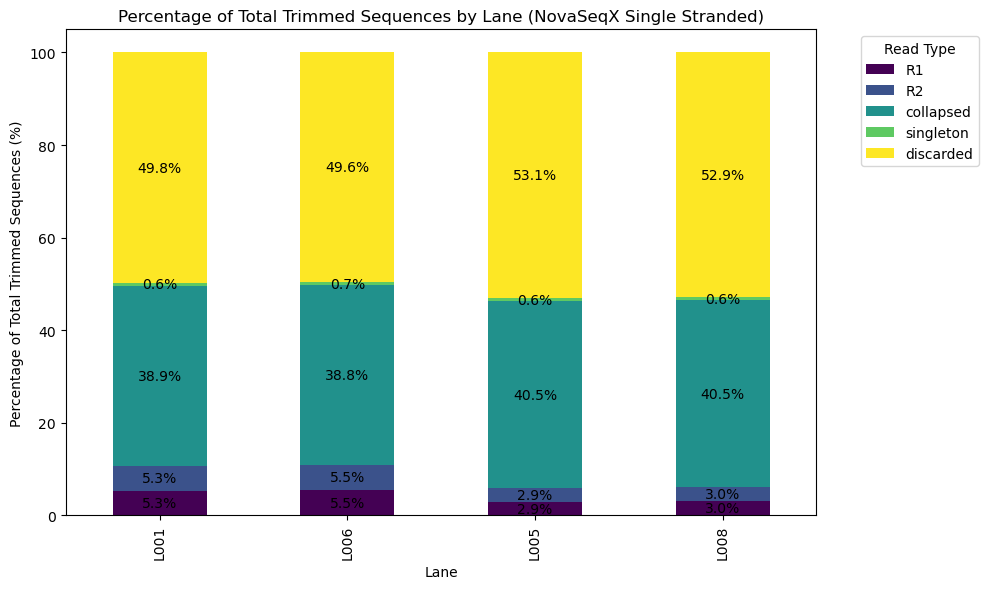

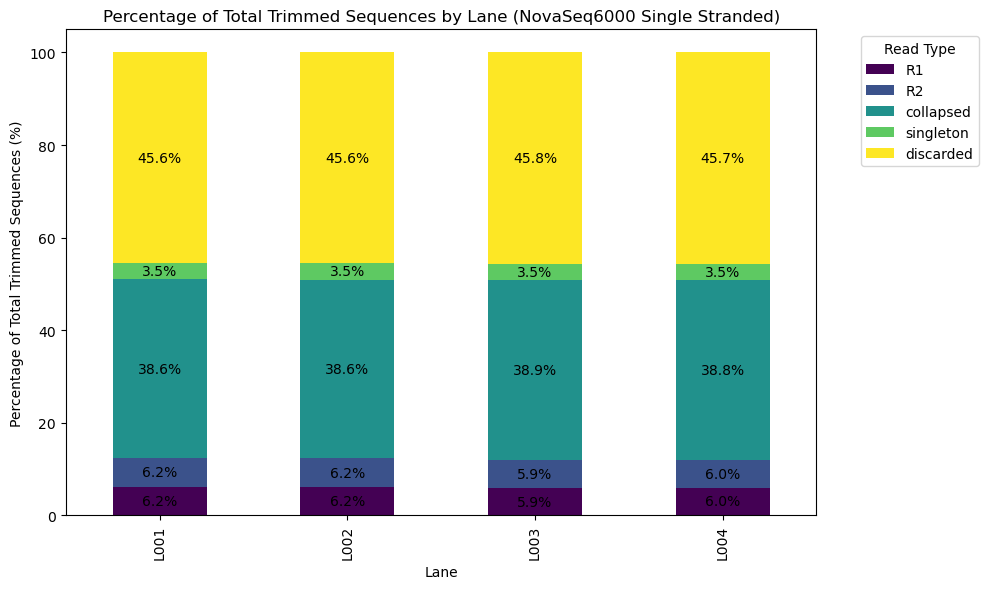

In [22]:
group = data_nsX[data_nsX["Protocol"] == "Single"][["Lane", "Read Type" , "fastqc_trimmed__Total Sequences", 'fastqc_raw__Total Sequences']].groupby(["Lane", "Read Type"]).sum()
group_reset = group[group["fastqc_trimmed__Total Sequences"] > 0].reset_index()

# Calculate the total sequences per Lane for normalization
group_reset["Total_Per_Lane"] = group_reset.groupby("Lane")['fastqc_raw__Total Sequences'].transform("sum")

# Calculate the percentage for each Read Type
group_reset["Percentage"] = (group_reset["fastqc_trimmed__Total Sequences"] / group_reset["Total_Per_Lane"]) * 100

# Pivot to prepare the data for the plot (use percentages)
pivot_data_percentage = group_reset.pivot(index="Lane", columns="Read Type", values="Percentage")

pivot_data_percentage= pivot_data_percentage.loc[["L001", "L006", "L005", "L008"]]

pivot_data_percentage['discarded'] = 100 - (pivot_data_percentage['R1'] + pivot_data_percentage['R2'] + pivot_data_percentage['collapsed'] + pivot_data_percentage['singleton'])

# Plot the stacked bar chart with percentages
ax = pivot_data_percentage.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')  # Display percentages with one decimal place

# Add labels and title
plt.title("Percentage of Total Trimmed Sequences by Lane (NovaSeqX Single Stranded)")
plt.xlabel("Lane")
plt.ylabel("Percentage of Total Trimmed Sequences (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

group = data_ns6[data_ns6["Protocol"] == "Single"][["Lane", "Read Type" , "fastqc_trimmed__Total Sequences", 'fastqc_raw__Total Sequences']].groupby(["Lane", "Read Type"]).sum()
group_reset = group[group["fastqc_trimmed__Total Sequences"] > 0].reset_index()

# Calculate the total sequences per Lane for normalization
group_reset["Total_Per_Lane"] = group_reset.groupby("Lane")["fastqc_raw__Total Sequences"].transform("sum")

# Calculate the percentage for each Read Type
group_reset["Percentage"] = (group_reset["fastqc_trimmed__Total Sequences"] / group_reset["Total_Per_Lane"]) * 100

# Pivot to prepare the data for the plot (use percentages)
pivot_data_percentage = group_reset.pivot(index="Lane", columns="Read Type", values="Percentage")

pivot_data_percentage= pivot_data_percentage.loc[["L001", "L002", "L003", "L004"]]

pivot_data_percentage['discarded'] = 100 - (pivot_data_percentage['R1'] + pivot_data_percentage['R2'] + pivot_data_percentage['collapsed'] + pivot_data_percentage['singleton'])


# Plot the stacked bar chart with percentages
ax = pivot_data_percentage.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')  # Display percentages with one decimal place

# Add labels and title
plt.title("Percentage of Total Trimmed Sequences by Lane (NovaSeq6000 Single Stranded)")
plt.xlabel("Lane")
plt.ylabel("Percentage of Total Trimmed Sequences (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
group_reset_nsX['Read Type' == 'collapsed']

,Platform,Read Type,fastqc_trimmed__Total Sequences,fastqc_raw__Total Sequences,Total_Per_Lane,Percentage
0,NovaSeq6,R1,1.391275e+09,1.145629e+10,2.291258e+10,6.072101
1,NovaSeq6,R2,1.391275e+09,1.145629e+10,2.291258e+10,6.072101
2,NovaSeq6,collapsed,8.870554e+09,0.000000e+00,2.291258e+10,38.714779
3,NovaSeq6,singleton,7.955850e+08,0.000000e+00,2.291258e+10,3.472263
4,NovaSeqX,R1,9.983557e+08,1.256158e+10,2.512316e+10,3.973846
5,NovaSeqX,R2,9.983557e+08,1.256158e+10,2.512316e+10,3.973846
6,NovaSeqX,collapsed,9.987179e+09,0.000000e+00,2.512316e+10,39.752871
7,NovaSeqX,singleton,1.512535e+08,0.000000e+00,2.512316e+10,0.602048


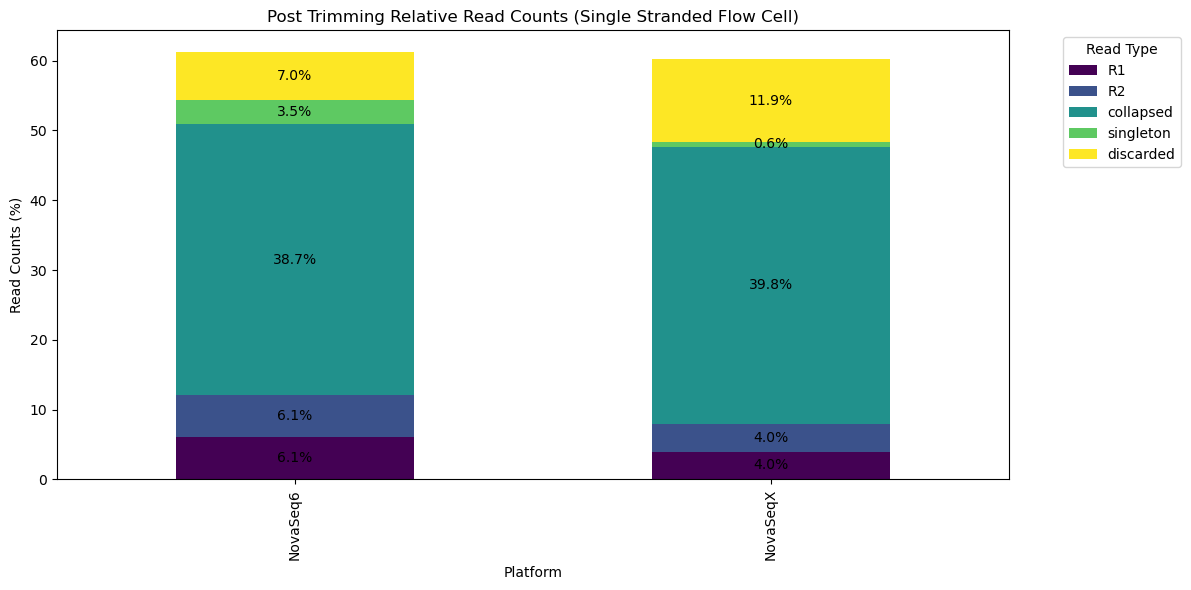

In [24]:
# Process NSX data (L005)
group_nsX = all_multiqc_data[all_multiqc_data["Protocol"] == "Single"][["Platform", "Read Type", "fastqc_trimmed__Total Sequences", "fastqc_raw__Total Sequences"]].groupby(["Platform", "Read Type"]).sum()
group_reset_nsX = group_nsX[group_nsX["fastqc_trimmed__Total Sequences"] > 0].reset_index()
group_reset_nsX["Total_Per_Lane"] = group_reset_nsX.groupby("Platform")["fastqc_raw__Total Sequences"].transform("sum")
group_reset_nsX["Percentage"] = (group_reset_nsX["fastqc_trimmed__Total Sequences"] / group_reset_nsX["Total_Per_Lane"]) * 100



pivot_nsX = group_reset_nsX.pivot(index="Platform", columns="Read Type", values="Percentage")
pivot_nsX["discarded"] = 100 - (pivot_nsX["R1"] + pivot_nsX["R2"] + pivot_nsX["collapsed"] + pivot_nsX["singleton"])


# Combine data for L004 and L005
pivot_nsX.index.name = "Platform"

# Plot combined data
ax = pivot_nsX.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")  # Display percentages with one decimal place

# Add labels and title
plt.title("Post Trimming Relative Read Counts (Single Stranded Flow Cell)")
plt.xlabel("Platform")
plt.ylabel("Read Counts (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Output from fastp Double stranded

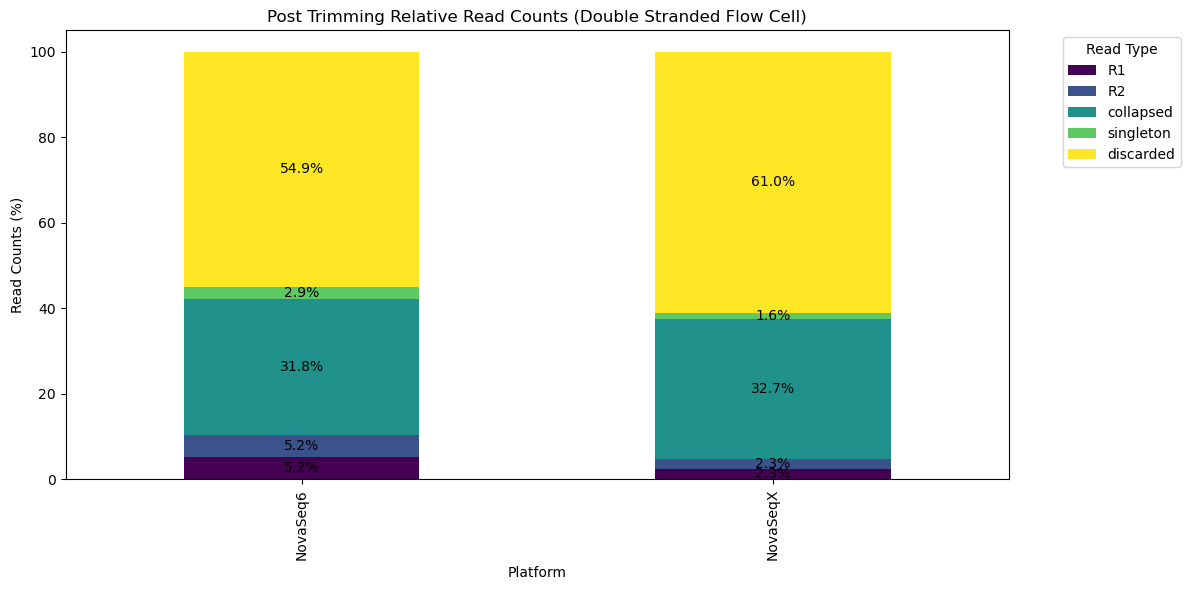

In [241]:
# Process NSX data (L005)
group_nsX = all_multiqc_data[(all_multiqc_data["Protocol"] == "Double") & (all_multiqc_data['Lane'])][["Platform", "Read Type", "fastqc_trimmed__Total Sequences", "fastqc_raw__Total Sequences"]].groupby(["Platform", "Read Type"]).sum()
group_reset_nsX = group_nsX[group_nsX["fastqc_trimmed__Total Sequences"] > 0].reset_index()
group_reset_nsX["Total_Per_Lane"] = group_reset_nsX.groupby("Platform")["fastqc_raw__Total Sequences"].transform("sum")
group_reset_nsX["Percentage"] = (group_reset_nsX["fastqc_trimmed__Total Sequences"] / group_reset_nsX["Total_Per_Lane"]) * 100

pivot_nsX = group_reset_nsX.pivot(index="Platform", columns="Read Type", values="Percentage")
pivot_nsX["discarded"] = 100 - (pivot_nsX["R1"] + pivot_nsX["R2"] + pivot_nsX["collapsed"] + pivot_nsX["singleton"])


# Combine data for L004 and L005
pivot_nsX.index.name = "Platform"

# Plot combined data
ax = pivot_nsX.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")

# Annotate the percentages on the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")  # Display percentages with one decimal place

# Add labels and title
plt.title("Post Trimming Relative Read Counts (Double Stranded Flow Cell)")
plt.xlabel("Platform")
plt.ylabel("Read Counts (%)")
plt.legend(title="Read Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Median sequence length double stranded collapsed

In [243]:
data_ns6_ds['fastqc_trimmed__median_sequence_length'].min()

34.0

C:\Users\glj523\AppData\Local\Temp\ipykernel_5392\1215165101.py:24: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



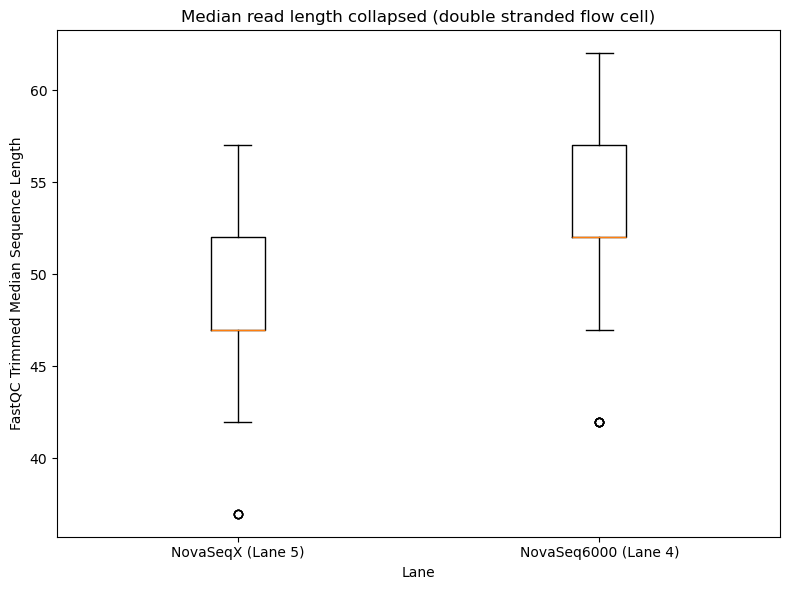

In [237]:
# Define the read type
read_type = "collapsed"
stat = 'fastqc_trimmed__median_sequence_length'

# Filter and prepare data for L005 (NSX) and L004 (NS6)
data_nsX_filtered = data_nsX_ds[
    (~data_nsX_ds[stat].isna()) 
    & (data_nsX_ds["Read Type"] == read_type)
]
data_ns6_filtered = data_ns6_ds[
    (~data_ns6_ds[stat].isna()) 
    & (data_ns6_ds["Read Type"] == read_type)
]

# Extract the median sequence lengths for the specified lanes
median_nsX = data_nsX_filtered[data_nsX_filtered["Lane"] == "L005"][stat]
median_ns6 = data_ns6_filtered[data_ns6_filtered["Lane"] == "L004"][stat]

# Combine the data into a single DataFrame for plotting
boxplot_data = {"NovaSeqX (Lane 5)": median_nsX, "NovaSeq6000 (Lane 4)": median_ns6}

# Create a single boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(boxplot_data.values(), labels=boxplot_data.keys())

# Add labels and title
plt.title(f"Median read length {read_type} (double stranded flow cell)")
plt.ylabel("FastQC Trimmed Median Sequence Length")
plt.xlabel("Lane")
plt.tight_layout()

# Show the combined plot
plt.show()


Median sequence length double stranded singleton

In [ ]:
# Filter the data for the specific conditions
filtered_data = data_nsX_ds[
    (data_nsX_ds['Lane'] == 'L005') & (data_nsX_ds['Read Type'] == 'singleton')
]

# Create the bar plot
fig = px.bar(
    data_frame=filtered_data,
    x="library_id",
    y="fastqc_trimmed__median_sequence_length",
    title="Median Sequence Length by Library ID (L005 - singleton, double)",
    labels={
        "library_id": "Library ID",
        "fastqc_trimmed__median_sequence_length": "Median Sequence Length"
    }
)

# Rotate x-axis labels
fig.update_layout(
    xaxis_tickangle=90,  # Rotate x-axis labels 90 degrees
    height=600,         # Adjust the height of the plot
    width=1000          # Adjust the width of the plot
)

# Show the plot
fig.show()


In [261]:
data_ns6_ds.Lane.unique()

array(['collapsed', 'collapsed.bact', 'collapsed.norway.1-of-7',
       'collapsed.norway.2-of-7', 'collapsed.norway.3-of-7',
       'collapsed.norway.4-of-7', 'collapsed.norway.5-of-7',
       'collapsed.norway.6-of-7', 'collapsed.norway.7-of-7',
       'collapsed.nt.1-of-9', 'collapsed.nt.2-of-9',
       'collapsed.nt.3-of-9', 'collapsed.nt.4-of-9',
       'collapsed.nt.5-of-9', 'collapsed.nt.6-of-9',
       'collapsed.nt.7-of-9', 'collapsed.nt.8-of-9',
       'collapsed.nt.9-of-9', 'collapsed.polar.1-of-1', 'collapsed.polar',
       'collapsed.refseq', 'L001', 'L002', 'L003', 'L004'], dtype=object)

In [263]:
data_nsX_ds.Lane.unique()

array(['L005', 'collapsed', 'collapsed.bact', 'collapsed.norway.1-of-7',
       'collapsed.norway.2-of-7', 'collapsed.norway.3-of-7',
       'collapsed.norway.4-of-7', 'collapsed.norway.5-of-7',
       'collapsed.norway.6-of-7', 'collapsed.norway.7-of-7',
       'collapsed.nt.1-of-9', 'collapsed.nt.2-of-9',
       'collapsed.nt.3-of-9', 'collapsed.nt.4-of-9',
       'collapsed.nt.5-of-9', 'collapsed.nt.6-of-9',
       'collapsed.nt.7-of-9', 'collapsed.nt.8-of-9',
       'collapsed.nt.9-of-9', 'collapsed.polar.1-of-1', 'collapsed.polar',
       'collapsed.refseq'], dtype=object)

In [266]:
data_nsX_ss.Lane.unique()

array(['L001', 'collapsed', 'collapsed.bact', 'collapsed.norway.1-of-7',
       'collapsed.norway.2-of-7', 'collapsed.norway.3-of-7',
       'collapsed.norway.4-of-7', 'collapsed.norway.5-of-7',
       'collapsed.norway.6-of-7', 'collapsed.norway.7-of-7',
       'collapsed.nt.1-of-9', 'collapsed.nt.2-of-9',
       'collapsed.nt.3-of-9', 'collapsed.nt.4-of-9',
       'collapsed.nt.5-of-9', 'collapsed.nt.6-of-9',
       'collapsed.nt.7-of-9', 'collapsed.nt.8-of-9',
       'collapsed.nt.9-of-9', 'collapsed.polar.1-of-1', 'collapsed.polar',
       'collapsed.refseq', 'L006', 'L005', 'L008', 'L004', 'L002', 'L003',
       'L007'], dtype=object)

In [260]:
data_ns6_ss.Lane.unique()

array(['collapsed', 'collapsed.bact', 'collapsed.norway.1-of-7',
       'collapsed.norway.2-of-7', 'collapsed.norway.3-of-7',
       'collapsed.norway.4-of-7', 'collapsed.norway.5-of-7',
       'collapsed.norway.6-of-7', 'collapsed.norway.7-of-7',
       'collapsed.nt.1-of-9', 'collapsed.nt.2-of-9',
       'collapsed.nt.3-of-9', 'collapsed.nt.4-of-9',
       'collapsed.nt.5-of-9', 'collapsed.nt.6-of-9',
       'collapsed.nt.7-of-9', 'collapsed.nt.8-of-9',
       'collapsed.nt.9-of-9', 'collapsed.polar.1-of-1', 'collapsed.polar',
       'collapsed.refseq', 'L001', 'L002', 'L003', 'L004'], dtype=object)

In [257]:
# Filter the data for the specific conditions
filtered_data = data_ns6_ds[
    (data_ns6_ds['Lane'] == 'L004') & (data_ns6_ds['Read Type'] == 'singleton')
]

# Create the bar plot
fig = px.bar(
    data_frame=filtered_data,
    x="library_id",
    y="fastqc_trimmed__median_sequence_length",
    title="Median Sequence Length by Library ID (L004 - singleton, double)",
    labels={
        "library_id": "Library ID",
        "fastqc_trimmed__median_sequence_length": "Median Sequence Length"
    }
)

# Rotate x-axis labels
fig.update_layout(
    xaxis_tickangle=90,  # Rotate x-axis labels 90 degrees
    height=600,         # Adjust the height of the plot
    width=1000          # Adjust the width of the plot
)

# Show the plot
fig.show()


In [259]:
# Filter the data for the specific conditions
filtered_data = data_ns6_ss[
    (data_ns6_ss['Lane'] == 'L004') & (data_ns6_ss['Read Type'] == 'singleton')
]

# Create the bar plot
fig = px.bar(
    data_frame=filtered_data,
    x="library_id",
    y="fastqc_trimmed__median_sequence_length",
    title="Median Sequence Length by Library ID (L004 - singleton, single)",
    labels={
        "library_id": "Library ID",
        "fastqc_trimmed__median_sequence_length": "Median Sequence Length"
    }
)

# Rotate x-axis labels
fig.update_layout(
    xaxis_tickangle=90,  # Rotate x-axis labels 90 degrees
    height=600,         # Adjust the height of the plot
    width=1000          # Adjust the width of the plot
)

# Show the plot
fig.show()


In [253]:
# Filter the data for the specific conditions
filtered_data = data_nsX_ss[
    (data_nsX_ss['Lane'] == 'L005') & (data_nsX_ss['Read Type'] == 'singleton')
]

# Create the bar plot
fig = px.bar(
    data_frame=filtered_data,
    x="library_id",
    y="fastqc_trimmed__median_sequence_length",
    title="Median Sequence Length by Library ID (L005 - singleton, single)",
    labels={
        "library_id": "Library ID",
        "fastqc_trimmed__median_sequence_length": "Median Sequence Length"
    }
)

# Rotate x-axis labels
fig.update_layout(
    xaxis_tickangle=90,  # Rotate x-axis labels 90 degrees
    height=600,         # Adjust the height of the plot
    width=1000          # Adjust the width of the plot
)

# Show the plot
fig.show()


In [222]:
# Filter the data for the specific conditions
filtered_data = data_nsX_ds[
    (data_nsX_ds['Lane'] == 'L005') & (data_nsX_ds['Read Type'] == 'collapsed')
]

# Create the bar plot
fig = px.bar(
    data_frame=filtered_data,
    x="library_id",
    y="fastqc_trimmed__median_sequence_length",
    title="Median Sequence Length by Library ID (L005 - Collapsed)",
    labels={
        "library_id": "Library ID",
        "fastqc_trimmed__median_sequence_length": "Median Sequence Length"
    }
)

# Rotate x-axis labels
fig.update_layout(
    xaxis_tickangle=90,  # Rotate x-axis labels 90 degrees
    height=600,         # Adjust the height of the plot
    width=1000          # Adjust the width of the plot
)

# Show the plot
fig.show()


C:\Users\glj523\AppData\Local\Temp\ipykernel_5392\4157707875.py:24: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



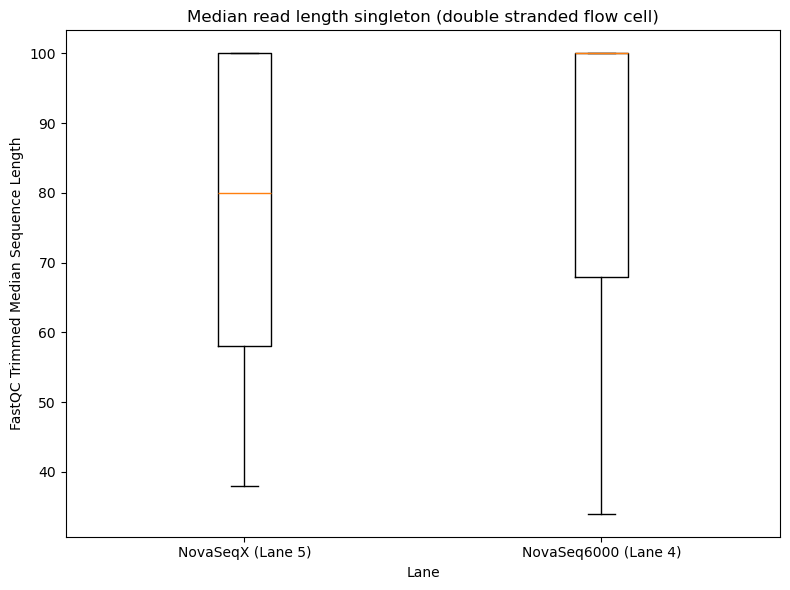

In [234]:
# Define the read type
read_type = "singleton"
stat = 'fastqc_trimmed__median_sequence_length'

# Filter and prepare data for L005 (NSX) and L004 (NS6)
data_nsX_filtered = data_nsX_ds[
    (~data_nsX_ds[stat].isna()) 
    & (data_nsX_ds["Read Type"] == read_type)
]
data_ns6_filtered = data_ns6_ds[
    (~data_ns6_ds[stat].isna()) 
    & (data_ns6_ds["Read Type"] == read_type)
]

# Extract the median sequence lengths for the specified lanes
median_nsX = data_nsX_filtered[data_nsX_filtered["Lane"] == "L005"][stat]
median_ns6 = data_ns6_filtered[data_ns6_filtered["Lane"] == "L004"][stat]

# Combine the data into a single DataFrame for plotting
boxplot_data = {"NovaSeqX (Lane 5)": median_nsX, "NovaSeq6000 (Lane 4)": median_ns6}

# Create a single boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(boxplot_data.values(), labels=boxplot_data.keys())

# Add labels and title
plt.title(f"Median read length {read_type} (double stranded flow cell)")
plt.ylabel("FastQC Trimmed Median Sequence Length")
plt.xlabel("Lane")
plt.tight_layout()

# Show the combined plot
plt.show()


Median seq length collapsed single stranded

C:\Users\glj523\AppData\Local\Temp\ipykernel_5392\2537991095.py:24: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



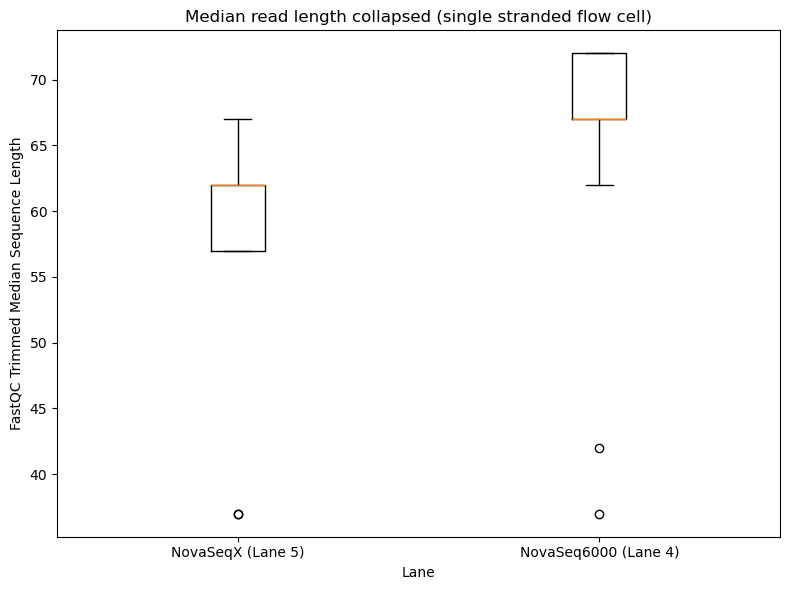

In [235]:
# Define the read type
read_type = "collapsed"
stat = 'fastqc_trimmed__median_sequence_length'

# Filter and prepare data for L005 (NSX) and L004 (NS6)
data_nsX_filtered = data_nsX_ss[
    (~data_nsX_ss[stat].isna()) 
    & (data_nsX_ss["Read Type"] == read_type)
]
data_ns6_filtered = data_ns6_ss[
    (~data_ns6_ss[stat].isna()) 
    & (data_ns6_ss["Read Type"] == read_type)
]

# Extract the median sequence lengths for the specified lanes
median_nsX = data_nsX_filtered[data_nsX_filtered["Lane"] == "L005"][stat]
median_ns6 = data_ns6_filtered[data_ns6_filtered["Lane"] == "L004"][stat]

# Combine the data into a single DataFrame for plotting
boxplot_data = {"NovaSeqX (Lane 5)": median_nsX, "NovaSeq6000 (Lane 4)": median_ns6}

# Create a single boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(boxplot_data.values(), labels=boxplot_data.keys())

# Add labels and title
plt.title(f"Median read length {read_type} (single stranded flow cell)")
plt.ylabel("FastQC Trimmed Median Sequence Length")
plt.xlabel("Lane")
plt.tight_layout()

# Show the combined plot
plt.show()

Median seq length singleton single stranded

C:\Users\glj523\AppData\Local\Temp\ipykernel_5392\729954140.py:24: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



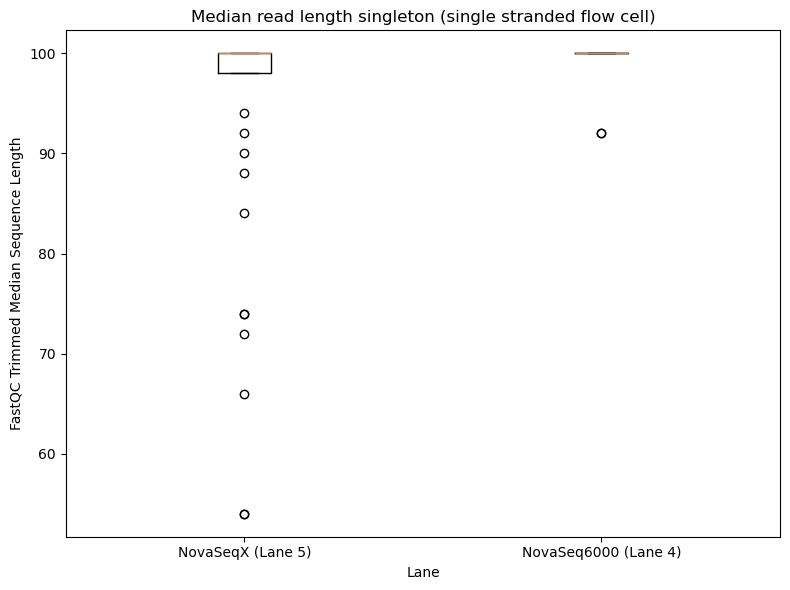

In [188]:
# Define the read type
read_type = "singleton"
stat = 'fastqc_trimmed__median_sequence_length'

# Filter and prepare data for L005 (NSX) and L004 (NS6)
data_nsX_filtered = data_nsX_ss[
    (~data_nsX_ss[stat].isna()) 
    & (data_nsX_ss["Read Type"] == read_type)
]
data_ns6_filtered = data_ns6_ss[
    (~data_ns6_ss[stat].isna()) 
    & (data_ns6_ss["Read Type"] == read_type)
]

# Extract the median sequence lengths for the specified lanes
median_nsX = data_nsX_filtered[data_nsX_filtered["Lane"] == "L005"][stat]
median_ns6 = data_ns6_filtered[data_ns6_filtered["Lane"] == "L004"][stat]

# Combine the data into a single DataFrame for plotting
boxplot_data = {"NovaSeqX (Lane 5)": median_nsX, "NovaSeq6000 (Lane 4)": median_ns6}

# Create a single boxplot
plt.figure(figsize=(8, 6))
plt.boxplot(boxplot_data.values(), labels=boxplot_data.keys())

# Add labels and title
plt.title(f"Median read length {read_type} (single stranded flow cell)")
plt.ylabel("FastQC Trimmed Median Sequence Length")
plt.xlabel("Lane")
plt.tight_layout()

# Show the combined plot
plt.show()

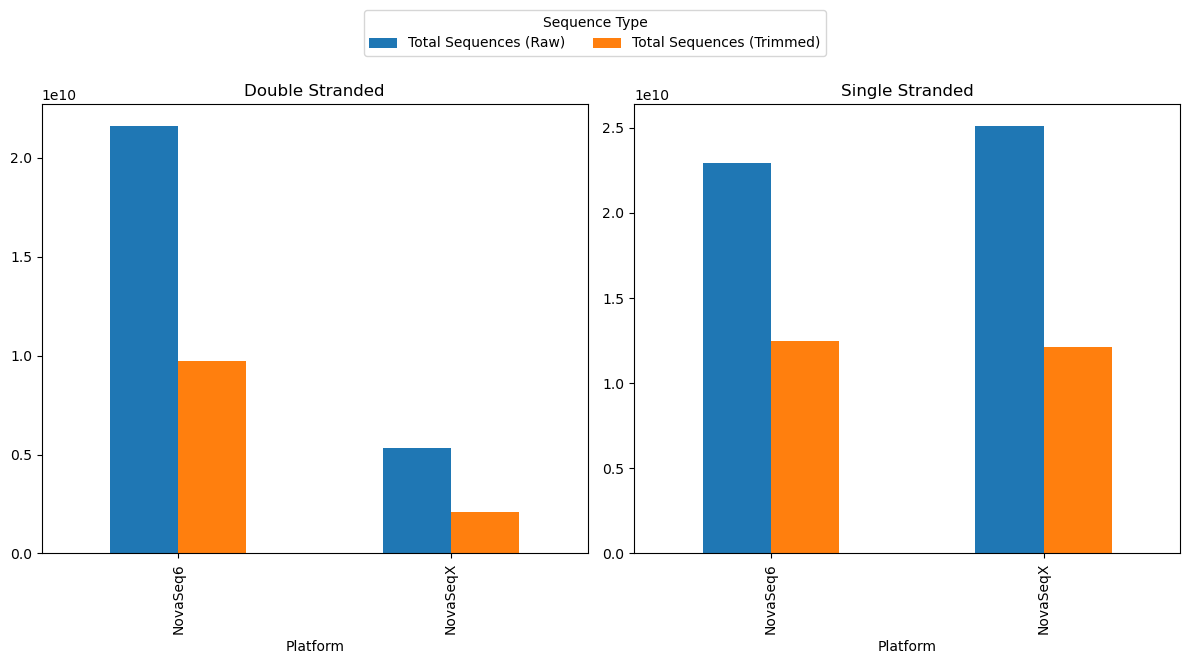

In [ ]:
def make_sum_plot_1(column1, column2, combined_df):
    combined_df[column1] = combined_df[column1].astype(float)
    combined_df[column2] = combined_df[column2].astype(float)

    double_df = combined_df[combined_df['Protocol'] == 'Double']
    single_df = combined_df[combined_df['Protocol'] == 'Single']
    # Calculate mean values for each platform and each sequencing type
    raw_sum_double = double_df.groupby('Platform')[column1].sum()

    trimmed_sum_double = double_df.groupby('Platform')[column2].sum()

    raw_sum_single = single_df.groupby('Platform')[column1].sum()

    trimmed_sum_single = single_df.groupby('Platform')[column2].sum()

    # Combine data into a DataFrame for easier plotting
    combined_sums_double = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_double,
        'Total Sequences (Trimmed)': trimmed_sum_double
    })

    # Combine data into a DataFrame for easier plotting
    combined_sums_single = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_single,
        'Total Sequences (Trimmed)': trimmed_sum_single
    })

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    combined_sums_double.plot(kind='bar', ax=ax[0], title="Double Stranded", legend=False)
    combined_sums_single.plot(kind='bar', ax=ax[1], title="Single Stranded", legend=False)

    handles, labels = ax[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Sequence Type")

    plt.tight_layout()
    plt.show()
make_sum_plot_1('fastqc_raw__Total Sequences', 'fastqc_trimmed__Total Sequences', all_multiqc_data)

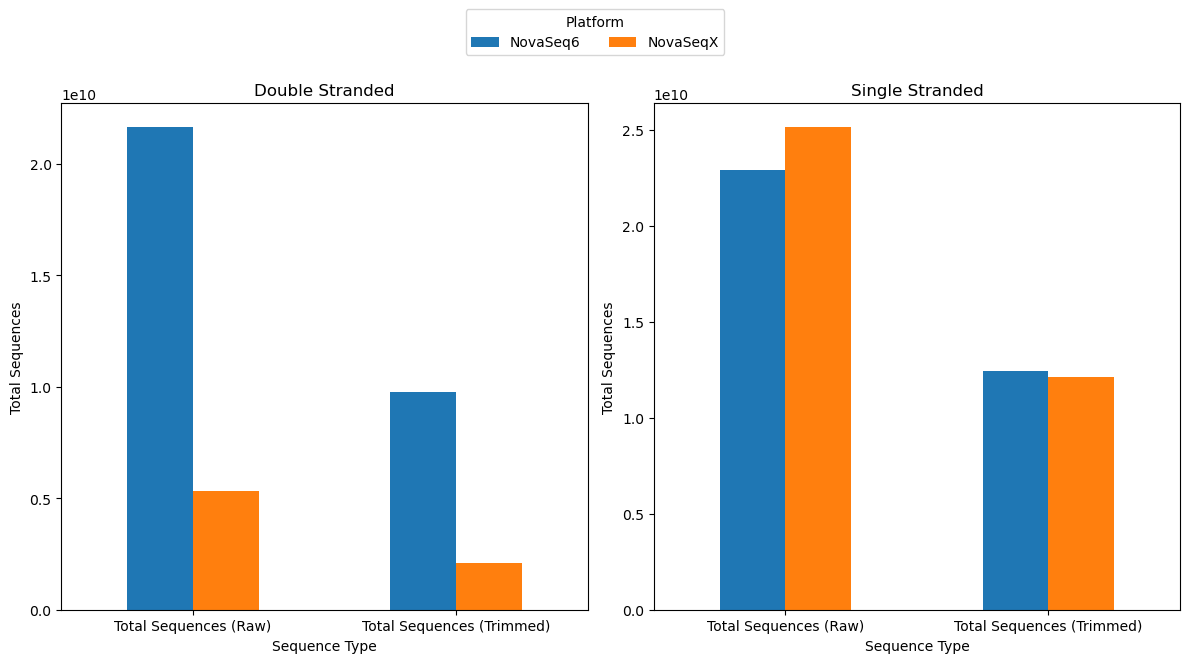

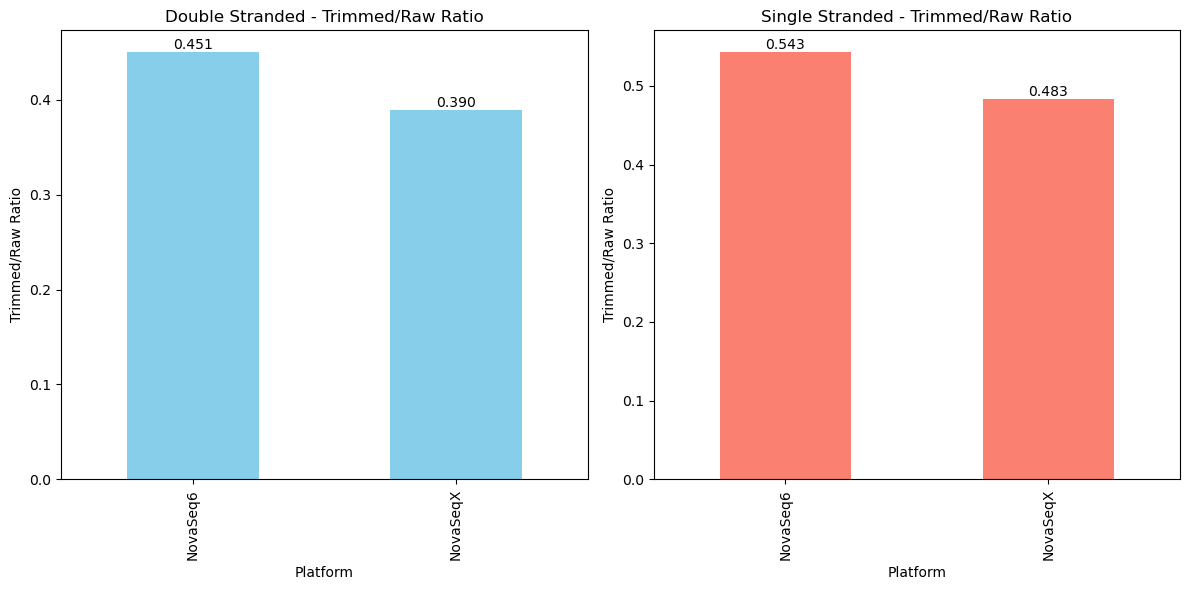

In [ ]:
def plot2(double_data, single_data):
    double_df = double_data
    single_df = single_data
    # Calculate mean values for each platform and each sequencing type
    raw_sum_double = double_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
    trimmed_sum_double = double_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

    raw_sum_single = single_df.groupby('Platform')['fastqc_raw__Total Sequences'].sum()
    trimmed_sum_single = single_df.groupby('Platform')['fastqc_trimmed__Total Sequences'].sum()

    # Combine data into a DataFrame for easier plotting
    combined_sums_double = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_double,
        'Total Sequences (Trimmed)': trimmed_sum_double
    }).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

    combined_sums_single = pd.DataFrame({
        'Total Sequences (Raw)': raw_sum_single,
        'Total Sequences (Trimmed)': trimmed_sum_single
    }).reset_index().melt(id_vars='Platform', var_name='Sequence Type', value_name='Total Sequences')

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Plot for Double Stranded
    combined_sums_double.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[0], rot=0, legend=False)
    ax[0].set_title("Double Stranded")
    ax[0].set_ylabel("Total Sequences")

    # Plot for Single Stranded
    combined_sums_single.pivot(index='Sequence Type', columns='Platform', values='Total Sequences').plot(kind='bar', ax=ax[1], rot=0, legend=False)
    ax[1].set_title("Single Stranded")
    ax[1].set_ylabel("Total Sequences")

    # Adding legend
    handles, labels = ax[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, title="Platform")

    plt.tight_layout()
    plt.show()

    
    # Calculate the ratio of trimmed to raw sequences
    ratio_double = (trimmed_sum_double / raw_sum_double).reset_index(name='Trimmed/Raw Ratio')
    ratio_single = (trimmed_sum_single / raw_sum_single).reset_index(name='Trimmed/Raw Ratio')

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Plot for Double Stranded ratios
    ratio_double.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[0], color='skyblue', legend=False)
    ax[0].set_title("Double Stranded - Trimmed/Raw Ratio")
    ax[0].set_ylabel("Trimmed/Raw Ratio")
    ax[0].set_xlabel("Platform")

    # Annotate the bars with the ratio values
    for i, value in enumerate(ratio_double['Trimmed/Raw Ratio']):
        ax[0].text(i, value, f"{value:.3f}", ha='center', va='bottom')

    # Plot for Single Stranded ratios
    ratio_single.plot(kind='bar', x='Platform', y='Trimmed/Raw Ratio', ax=ax[1], color='salmon', legend=False)
    ax[1].set_title("Single Stranded - Trimmed/Raw Ratio")
    ax[1].set_ylabel("Trimmed/Raw Ratio")
    ax[1].set_xlabel("Platform")

    # Annotate the bars with the ratio values
    for i, value in enumerate(ratio_single['Trimmed/Raw Ratio']):
        ax[1].text(i, value, f"{value:.3f}", ha='center', va='bottom')

    plt.tight_layout()
    plt.show()
plot2(all_multiqc_data[all_multiqc_data["Protocol"] == "Double"], all_multiqc_data[all_multiqc_data["Protocol"] == "Single"])

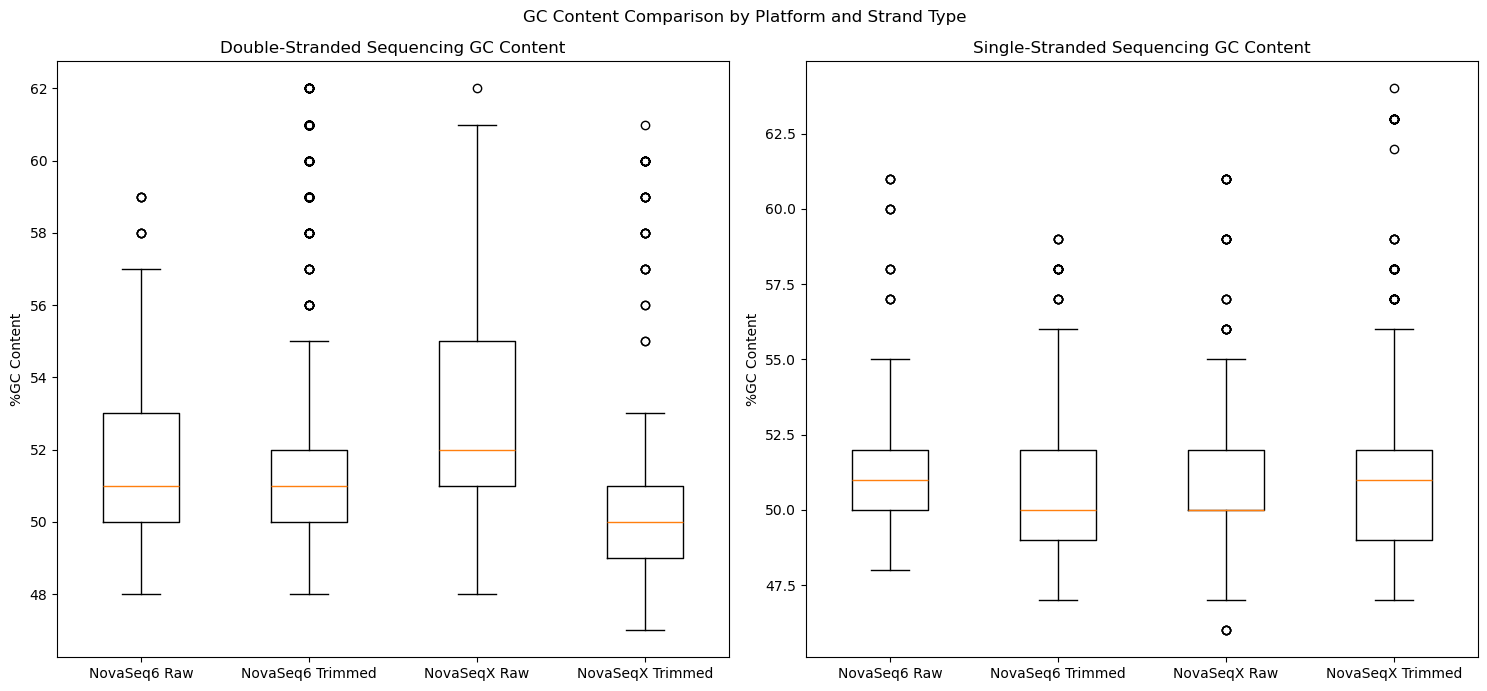

In [ ]:
def make_boxplots(data, data_types, platforms, title, ax):
    gc_data = []
    labels = []

    for platform in platforms:
        for data_type in data_types:
            gc_content = data[data['Platform'] == platform][data_type].dropna()
            gc_data.append(gc_content)
            labels.append(f'{platform} {"Raw" if "raw" in data_type else "Trimmed"}')
    
    ax.boxplot(gc_data, tick_labels=labels)
    ax.set_title(title)
    ax.set_ylabel('%GC Content')

# Set up the plot
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# Platforms
platforms = all_multiqc_data["Platform"].unique()

describe_cols = [r"fastqc_raw__%GC", r"fastqc_trimmed__%GC"]

# Plot GC content for double-stranded and single-stranded sequencing
make_boxplots(all_multiqc_data[all_multiqc_data["Protocol"] == "Double"], describe_cols, platforms, 'Double-Stranded Sequencing GC Content', axs[0])
make_boxplots(all_multiqc_data[all_multiqc_data["Protocol"] == "Single"], describe_cols, platforms, 'Single-Stranded Sequencing GC Content', axs[1])

# Display the plot
plt.suptitle('GC Content Comparison by Platform and Strand Type')
plt.tight_layout()
plt.show()